# Libraries

In [1]:
import os
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import statsmodels.api as sm 
import seaborn as sns
import geopandas as gpd
import matplotlib.dates as mdates
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from scipy.stats import pearsonr
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.font_manager import FontProperties
import matplotlib
matplotlib.use('Agg')
%matplotlib inline 
plt.switch_backend('module://ipykernel.pylab.backend_inline')

# Inputs

In [ ]:
#Paths
pathEst = r'C:\path_rain_gauge_stations'  # Enter the path where the station files are located.
pathOutput = r'C:\path_output'  # Enter the path where you will save the output files.

In [3]:
#Lista de acceso 
listEst = [os.path.join(pathEst,arch) for arch in os.listdir(pathEst) if arch.endswith('csv')]
print("LA LISTA DE ESTACIONES SE MUESTRA A CONTINUACION")
listEst

LA LISTA DE ESTACIONES SE MUESTRA A CONTINUACION


['D:\\UAT_Doc\\Cap_libro_springer_2025\\2.Envio_CorreccionesAbril\\VSCode_Inputs\\RainGaugesTotal\\St30071.csv',
 'D:\\UAT_Doc\\Cap_libro_springer_2025\\2.Envio_CorreccionesAbril\\VSCode_Inputs\\RainGaugesTotal\\St30160.csv',
 'D:\\UAT_Doc\\Cap_libro_springer_2025\\2.Envio_CorreccionesAbril\\VSCode_Inputs\\RainGaugesTotal\\St30169.csv',
 'D:\\UAT_Doc\\Cap_libro_springer_2025\\2.Envio_CorreccionesAbril\\VSCode_Inputs\\RainGaugesTotal\\St30220.csv',
 'D:\\UAT_Doc\\Cap_libro_springer_2025\\2.Envio_CorreccionesAbril\\VSCode_Inputs\\RainGaugesTotal\\St30304.csv',
 'D:\\UAT_Doc\\Cap_libro_springer_2025\\2.Envio_CorreccionesAbril\\VSCode_Inputs\\RainGaugesTotal\\St30319.csv',
 'D:\\UAT_Doc\\Cap_libro_springer_2025\\2.Envio_CorreccionesAbril\\VSCode_Inputs\\RainGaugesTotal\\St30325.csv',
 'D:\\UAT_Doc\\Cap_libro_springer_2025\\2.Envio_CorreccionesAbril\\VSCode_Inputs\\RainGaugesTotal\\St30345.csv']

In [4]:
#Verificando las rutas
for arch_path in listEst:
    if not os.path.exists(arch_path):
        print(f'el archivo {arch_path} no existe')
        raise FileNotFoundError (f'El archivo {arch_path} no existe')

In [17]:
#Diccionario de almacenamiento
dataframes = {}  #En este diccionario se guardaran los csv iniciales
dfs_respaldo = {} #En este diccionario se guardaran los dataframes de respaldo
dfs_Estaciones = {}  #En este diccionario se guardaran los df de salida ["año_mes"],["pcp_mm"],["diasReg"]
dfs_pivotePCP = {} # En este diccionario se guardaran los archivos pivotes para la pcp 
dfs_pivotePCPRein ={} #En este diccionario se guardan las tablas pivote reindexadas de la pcp con el criterio de la OMM
dfs_pivoteDias = {}  # En este diccionario se guardan las tablas pivote para los dias de registro
dfs_pivoteDiasRein = {}  # En este diccionario se guardan las tablas pivote reindexadas de los dias de registro
dfs_pivotePCP_0 ={}   #En estee diccionario se guardan los originales de las tablas pivote de pcp
dfs_diasFilt={}
dfs_diasReindex_0={}


In [18]:
#Leyendo cada archivo de csv

for arch_path in listEst:
    nomEst = os.path.splitext(os.path.basename(arch_path))[0]
    try:
        df = pd.read_csv(arch_path)
        dataframes[nomEst] = df
    except Exception as e:
        print(f"Ocurrio un error al leer {arch_path}:{e}")


#Mostrar los nombres de las estaciones (Claves del diccionario)
print('Las estaciones se han asignado a dataframes')
print(list(dataframes.keys()))

Las estaciones se han asignado a dataframes
['St30071', 'St30160', 'St30169', 'St30220', 'St30304', 'St30319', 'St30325', 'St30345']


In [19]:
Estaciones = list(dataframes.keys())
Estaciones

['St30071',
 'St30160',
 'St30169',
 'St30220',
 'St30304',
 'St30319',
 'St30325',
 'St30345']

# First Treatment of the data

In [20]:
#Funcion para año bisiesto
def leap_year(year):
    return (year % 4==0 and (year%100!=0 or year % 400==0))

leap_year(2016)       #prueba


True

In [21]:
#Dias por mes
diasDelMes={'Ene':31,'Feb':28,'Mar':31,'Abr':30,'May':31,'Jun':30,'Jul':31,'Ago':31,'Sep':30,'Oct':31,'Nov':30,'Dic':31}
#Formula 
def PrimeraDepuracion(Estaciones,dataframes,dfs_pivotePCP,dfs_pivoteDias,pathtosaveP1,pathtosaveP2,pathtosaveP3,pathtosaveP4):
    for Est in Estaciones:
        df_1 = dataframes[Est]
        df_1['pcp_mm'] = pd.to_numeric(df_1['pcp_mm'], errors='coerce') 
       ###DIAS DE REGISTRO--------------------------------------------------------------------------------------------------
        Tabla_dias = df_1.pivot_table(index='year',columns='mes',values='pcp_mm',aggfunc='count')
        mes_columns = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
        Tabla_dias.columns=mes_columns  #Inserta el numero de mes en cada columna
        year01dr = Tabla_dias.index[0]
        yearFindr = Tabla_dias.index[-1]
        Difyeardr = yearFindr - year01dr
        dfs_pivoteDias[Est] = Tabla_dias    #Guardando en el diccionario

        #Generacion de nuevas matrices con la totalidad de los años (Dias de registro)---------------------------------------
        all_years = pd.Index(range(year01dr,yearFindr + 1), name='year')
        Tabla_diasReindex = Tabla_dias.reindex(all_years, fill_value=np.nan)
        Tabla_diasReindex.replace(0,np.nan, inplace=True)
        Tabla_diasFinal=Tabla_diasReindex  
        #Extracto de los años de registro 
        TablaDiasFilt = Tabla_diasFinal[(Tabla_diasFinal.index >= year01dr) & (Tabla_diasFinal.index <= yearFindr)]  #Filtra el numero de años
        Cuenta_Filas = TablaDiasFilt.count()             # Cuenta del numero de años con registros
        Cuenta_Filas.name = 'TotAñosReg'
        #Suma de los registros mensuales por año (Se agrega una columna)
        Tabla_diasFinal['TotalReg'] = Tabla_diasFinal.sum(axis=1)  #Suma de registros del año de forma horizontal
        #
        Total_Filas = Tabla_diasFinal.sum()    #Dias totales de registro en todo el periodo
        Total_Filas.name = 'TotalReg_mes'
        Tabla_diasFinal = pd.concat([Tabla_diasFinal,Total_Filas.to_frame().T])  #Total de dias registrados de ese mes 
        #
        Tabla_diasFinal = pd.concat([Tabla_diasFinal,Cuenta_Filas.to_frame().T])   #Años registrados
        #Años de registro  
        fila_Difyears =pd.Series(Difyeardr+1,index=Tabla_diasFinal.columns, name='Tot_años')  #Total de años de registro
        Tabla_diasFinal = pd.concat([Tabla_diasFinal,fila_Difyears.to_frame().T])
        #Registros diarios que deberia haber de ese mes de acuerdo al periodo de años
        datosEsperados = {mes:diasDelMes[mes] for mes in diasDelMes.keys()}
        for year in range(year01dr,yearFindr+1):
            for mes in diasDelMes.keys():
                if mes=='Feb' and leap_year(year):   #Considerando año bisiesto
                    datosEsperados[mes]+=29
                else:
                    datosEsperados[mes]+=diasDelMes[mes]
                    
        datosEsperados=pd.Series(datosEsperados,name='TotRegMensEsp')
        Tabla_diasFinal=pd.concat([Tabla_diasFinal,datosEsperados.to_frame().T])
        #Fila de porcentaje de datos faltantes
        PorcDatFalt= round(((Tabla_diasFinal.loc['TotRegMensEsp'] - Tabla_diasFinal.loc['TotalReg_mes'])/Tabla_diasFinal.loc['TotRegMensEsp']),2)
        PorcDatFalt.name='PorcDatFalt'               #Porcentaje de datos faltantes
        Tabla_diasFinal=pd.concat([Tabla_diasFinal,PorcDatFalt.to_frame().T])
        dfs_pivoteDiasRein[Est]=Tabla_diasFinal       #Guardando en el diccionario de dias reindexado
        dfs_diasFilt[Est]=TablaDiasFilt              #Guardando de bloque segmentado
        dfs_diasReindex_0[Est]=Tabla_diasReindex     #Guardando respaldo de dias reindexadados

        ###REGISTROS DE PRECIPITACION
        #Acumulados de precipitacion-----------------------------------------------------------------------------------------
        Tabla_pcp = df_1.pivot_table(index='year',columns='mes',values='pcp_mm',aggfunc='sum')
        mes_columnspcp = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
        Tabla_pcp.columns=mes_columnspcp
        year01pcp=Tabla_pcp.index[0]
        yearFinpcp=Tabla_pcp.index[-1]
        dfs_pivotePCP[Est] = Tabla_pcp   #Guardando en el diccionario
        all_yearspcp = pd.Index(range(year01pcp,yearFinpcp + 1), name='yearpcp')
        Tabla_PCPReindex = Tabla_pcp.reindex(all_yearspcp, fill_value=np.nan)
        Tabla_Finalpcp = Tabla_PCPReindex
        Tabla_Finalpcp_0=Tabla_Finalpcp
        #Descartando las pcp de los meses con 5 dias faltantes de registro OMM No.341
        for mes in Tabla_Finalpcp.columns:
            if mes=='Feb':
                Tabla_Finalpcp[mes]=np.where(TablaDiasFilt[mes]>23,Tabla_Finalpcp[mes],np.nan)
            else:
                Tabla_Finalpcp[mes]=np.where(TablaDiasFilt[mes]>25,Tabla_Finalpcp[mes],np.nan)


        dfs_pivotePCPRein[Est]=Tabla_Finalpcp    #Matriz con la totalidad de los años de pcp guardada en el diccionario con el criterio de la OMM
        dfs_pivotePCP_0[Est]=Tabla_Finalpcp_0    #Matriz con la totalidad de los años de pcp guardada en el diccionario

        
      
    with pd.ExcelWriter(pathtosaveP1) as writer:       #Precipitacion original
        for Est,df_Est in dfs_pivotePCP.items():
            df_Est.to_excel(writer,sheet_name=Est,index=True)

    with pd.ExcelWriter(pathtosaveP2) as writer:     #Precipitacion en la totalidad de los años con criterio de la OMM
        for Est, df_Est in dfs_pivotePCPRein.items():
            df_Est.to_excel(writer,sheet_name=Est,index=True)
    
    with pd.ExcelWriter(pathtosaveP3) as writer:     #Dias de Registro originales
        for Est,df_Est in dfs_pivoteDias.items():
            df_Est.to_excel(writer,sheet_name=Est,index=True)

    with pd.ExcelWriter(pathtosaveP4) as writer:       #dias de registro en la totalidad de los años
        for Est, df_Est in dfs_pivoteDiasRein.items():
            df_Est.to_excel(writer,sheet_name=Est,index=True)

    return(f'LOS ARCHIVOS HAN GUARDADO CORRECTAMENTE EN: {pathOutput}')
    

In [22]:
#RUTAS PARA LA PRIMERA DEPURACION
pathtosaveP1 = f'{pathOutput}\matriz_pcpFilt.xlsx'
pathtosaveP2 = f'{pathOutput}\matriz_PCPReindexFilt.xlsx'
pathtosaveP3 = f'{pathOutput}\matriz_diasregFilt.xlsx'
pathtosaveP4 = f'{pathOutput}\matriz_diasregReindexFilt.xlsx'

PrimeraDepuracion(Estaciones,dataframes,dfs_pivotePCP,dfs_pivoteDias,pathtosaveP1,pathtosaveP2,pathtosaveP3,pathtosaveP4)


'LOS ARCHIVOS HAN GUARDADO CORRECTAMENTE EN: D:\\UAT_Doc\\Cap_libro_springer_2025\\2.Envio_CorreccionesAbril\\VSCode_Comprobacion'

## Graphs of Missing Data per Month

Realizado


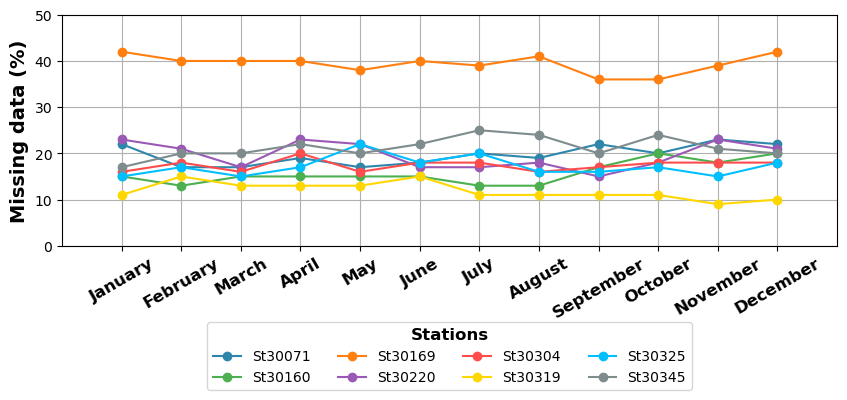

In [23]:
#Modificada
meses=['January','February','March','April','May','June','July','August','September','October','November','December']
colores  ={'St30071':'#2E86AB','St30160':'#4CAF50', 'St30169':'#FF7F11','St30220':'#9B59B6','St30304':'#FF4C4C','St30319':'#FFD700','St30325':'#00BFFF','St30345':'#7F8C8D'}

pathsave = pathOutput

plt.figure(figsize=(10,3))
for Estacion, df in dfs_pivoteDiasRein.items():
    if 'TotalReg' in df.columns:
        df=df.drop(columns='TotalReg')

    plt.plot(df.columns,df.loc['PorcDatFalt'].astype(float)*100,label=Estacion, marker='o', color = colores[Estacion])

plt.ylim(0,50)
plt.xlim(-1,12)
#plt.margins(y=0.5)
plt.yticks(ticks=np.arange(0,60,10))
plt.xticks(ticks=np.arange(0,12), labels=meses, rotation=30,fontsize=12, fontweight='bold')
plt.xlabel('',fontweight='bold')
plt.ylabel('Missing data (%)',fontsize=14,fontweight='bold')
plt.title('')
font_legend_title = FontProperties(weight='bold', size=12)
plt.legend(title='Stations',title_fontproperties=font_legend_title, loc='upper center', bbox_to_anchor=(0.5, -0.30), ncol=4)
plt.grid(True)
#plt.grid(True)
plt.savefig(f'{pathsave}\Est_Porc_Mes_Missing_rec.png',dpi=300, bbox_inches='tight', facecolor='w')

print('Realizado')

# Rainfall Timeseries (Rf)

### Timeseries convertion 

In [25]:
dfs_timeseries={}   #Diccionario donde se guardaran las series de tiempo
meses_a_numero={'Ene':1,'Feb':2,'Mar':3,'Abr':4,'May':5,'Jun':6,'Jul':7,'Ago':8,'Sep':9,'Oct':10,'Nov':11,'Dic':12}

In [26]:
#Convirtiendo las tabla pivote a series de tiempo completo
for Est in Estaciones:
    df_ts1 = dfs_pivotePCPRein[Est]
    #df_ts1.replace(np.nan,-1,inplace=True)
    df_ts2=pd.melt(df_ts1.reset_index(),id_vars='yearpcp',var_name='mes',value_name='pcp_mm')
    df_ts2['mes']=df_ts2['mes'].replace(meses_a_numero)
    df_ts2['date']=pd.to_datetime(df_ts2['yearpcp'].astype(str)+'-'+df_ts2['mes'].astype(str)+'-01')
    df_ts2=df_ts2.sort_values(by='date').reset_index(drop=True)
    df_ts2=df_ts2[['date','pcp_mm']]
    dfs_timeseries[Est]=df_ts2
    

C:\Users\Edgar Ruiz\AppData\Local\Temp\ipykernel_19640\2683993540.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ts2['mes']=df_ts2['mes'].replace(meses_a_numero)
C:\Users\Edgar Ruiz\AppData\Local\Temp\ipykernel_19640\2683993540.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ts2['mes']=df_ts2['mes'].replace(meses_a_numero)
C:\Users\Edgar Ruiz\AppData\Local\Temp\ipykernel_19640\2683993540.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old be

### Correlation Matrix

In [27]:
# Combinando los dataframes
df_PCPCombined = pd.DataFrame()        #Dataframe con todas las series de tiempo de todas las estaciones

for Est,df in dfs_timeseries.items():
    df=df.set_index('date')
  
  
    df_PCPCombined[Est]=df['pcp_mm']


df_PCPCombined.to_excel(f'{pathOutput}\Combined_Est.xlsx')
#print(df_PCPCombined.head())
df_PCPCombined

,St30071,St30160,St30169,St30220,St30304,St30319,St30325,St30345
date,,,,,,,,
1961-01-01,89.5,73.56,72.27,NaN,NaN,NaN,NaN,NaN
1961-02-01,25.0,0.03,28.00,NaN,NaN,NaN,NaN,NaN
1961-03-01,21.5,0.02,11.00,NaN,NaN,NaN,NaN,NaN
1961-04-01,1.0,6.01,0.00,NaN,NaN,NaN,NaN,NaN
1961-05-01,17.5,40.01,7.50,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2023-08-01,109.0,NaN,65.50,NaN,NaN,67.00,95.0,NaN
2023-09-01,15.5,NaN,0.00,NaN,NaN,0.00,8.0,NaN
2023-10-01,163.0,NaN,127.00,79.0,NaN,272.00,NaN,NaN


In [29]:
# Matriz de correlacion
corr_matrix = round(df_PCPCombined.corr(),2)
corr_matrix.to_excel(f'{pathOutput}\matriz_Correlacion.xlsx')
corr_matrix

,St30071,St30160,St30169,St30220,St30304,St30319,St30325,St30345
St30071,1.00,0.70,0.76,0.67,0.71,0.71,0.64,0.70
St30160,0.70,1.00,0.76,0.81,0.87,0.76,0.77,0.76
St30169,0.76,0.76,1.00,0.68,0.74,0.68,0.62,0.82
St30220,0.67,0.81,0.68,1.00,0.79,0.79,0.78,0.74
St30304,0.71,0.87,0.74,0.79,1.00,0.82,0.79,0.82
St30319,0.71,0.76,0.68,0.79,0.82,1.00,0.83,0.83
St30325,0.64,0.77,0.62,0.78,0.79,0.83,1.00,0.81
St30345,0.70,0.76,0.82,0.74,0.82,0.83,0.81,1.00


In [30]:
est_sinclave = [71,160,169,220,304,319,325,345]

matriz_claves = corr_matrix.copy()
matriz_claves.index = est_sinclave
matriz_claves.columns = est_sinclave
matriz_claves

,71,160,169,220,304,319,325,345
71,1.00,0.70,0.76,0.67,0.71,0.71,0.64,0.70
160,0.70,1.00,0.76,0.81,0.87,0.76,0.77,0.76
169,0.76,0.76,1.00,0.68,0.74,0.68,0.62,0.82
220,0.67,0.81,0.68,1.00,0.79,0.79,0.78,0.74
304,0.71,0.87,0.74,0.79,1.00,0.82,0.79,0.82
319,0.71,0.76,0.68,0.79,0.82,1.00,0.83,0.83
325,0.64,0.77,0.62,0.78,0.79,0.83,1.00,0.81
345,0.70,0.76,0.82,0.74,0.82,0.83,0.81,1.00


Realizado


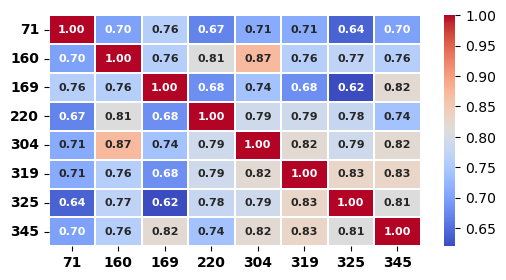

In [31]:
# Modificada Grafica de calor (Matriz de correlacion) 
plt.figure(figsize=(6,3))
sns.heatmap(matriz_claves, annot=True, cmap='coolwarm',fmt='.2f',annot_kws={'fontweight':'bold','size':8}, linewidths=0.1)
plt.title('')

plt.xticks(fontweight='bold', fontsize=10)
plt.yticks(fontweight='bold',fontsize=10, rotation=0)

plt.xlabel('')

plt.savefig(f'{pathsave}\CorrMatrix_reduc.png',dpi=300, bbox_inches='tight', facecolor='w')

print('Realizado')

### Missing Data Percentage

In [32]:
#Porcentaje de datos faltantes en la totalidad de la serie
Sum_Datos=df_PCPCombined.count()
Sum_Datos.name = 'Datos Totales'
Datos_Tot = df_PCPCombined.shape[0]
Porc_DatFalt = round(((Datos_Tot-Sum_Datos)/Datos_Tot),2)
Porc_DatFalt = Porc_DatFalt.to_frame(name ='Missing_Data')
Porc_DatFalt.index.name = 'Stations'
Porc_DatFalt

,Missing_Data
Stations,
St30071,0.19
St30160,0.20
St30169,0.55
St30220,0.33
St30304,0.41
St30319,0.33
St30325,0.39
St30345,0.49


C:\Users\Edgar Ruiz\AppData\Local\Temp\ipykernel_19640\2153900785.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Stations',y='Missing_Data',data=Porc_DatFalt*100, palette=ColoresGraf)


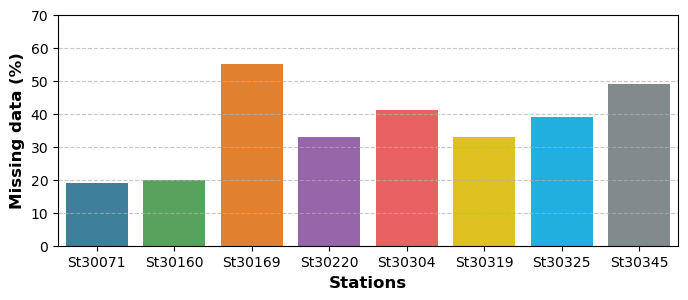

In [33]:
# Grafica de porcentaje modificada

colores ={'St30071':'#2E86AB','St30160':'#4CAF50', 'St30169':'#FF7F11','St30220':'#9B59B6','St30304':'#FF4C4C','St30319':'#FFD700','St30325':'#00BFFF','St30345':'#7F8C8D'}

ColoresGraf = [colores[Estacion] for Estacion in Porc_DatFalt.index]

plt.figure(figsize=(8,3))
sns.barplot(x='Stations',y='Missing_Data',data=Porc_DatFalt*100, palette=ColoresGraf)

plt.ylim(0,70)
plt.yticks(ticks=np.arange(0,80,10))
plt.xticks(fontsize=10)
plt.xlabel('Stations',fontsize=12,fontweight='bold')
plt.ylabel('Missing data (%)',fontsize=12, fontweight='bold')
plt.title('')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig(f'{pathsave}\TotalMissingData.png',dpi=300, bbox_inches='tight', facecolor='w')

plt.show()


### Selecting a continuous period

In [34]:
df_PeriodoPCP = df_PCPCombined.dropna()

df_PeriodoPCP.to_excel(f'{pathOutput}\PeriodoPCP.xlsx')

In [35]:
#De acuerdo a fechas
#Periodo
start_date2 = '2000-01-01'
end_date2 = '2013-12-01'

df_2doPeriodPCP_0 = df_PCPCombined.loc[start_date2:end_date2]     #Filas completas incluyendo datos faltantes
df_2doPeriodPCP = df_PCPCombined.loc[start_date2:end_date2].dropna()   #Eliminando filas con datos faltantes

df_2doPeriodPCP.to_excel(f'{pathOutput}\PeriodSelect_2_dropna.xlsx')
df_2doPeriodPCP_0.to_excel(f'{pathOutput}\PeriodSelect_2.xlsx')
df_2doPeriodPCP_copy = pd.DataFrame()
df_2doPeriodPCP_copy = df_2doPeriodPCP.copy()
df_2doPeriodPCP_copy

Stations,St30071,St30160,St30169,St30220,St30304,St30319,St30325,St30345
date,,,,,,,,
2000-07-01,3.8,11.0,29.8,24.0,19.10,16.30,9.0,15.5
2000-08-01,1.4,117.0,89.0,173.6,136.00,175.90,190.0,175.5
2000-10-01,16.0,197.5,60.0,58.0,209.00,199.20,157.0,72.5
2000-11-01,10.0,41.0,16.7,24.0,34.00,29.30,28.0,21.0
2000-12-01,11.0,18.0,34.3,46.0,25.00,50.20,36.0,45.0
...,...,...,...,...,...,...,...,...
2013-07-01,33.3,62.6,44.8,159.1,52.92,27.40,38.0,80.0
2013-08-01,147.5,304.9,176.5,209.0,198.72,134.00,193.0,175.0
2013-09-01,493.4,251.8,259.5,427.5,219.41,323.01,334.0,207.5


## Experimentation period

In [36]:
df_2doPeriodPCP

Stations,St30071,St30160,St30169,St30220,St30304,St30319,St30325,St30345
date,,,,,,,,
2000-07-01,3.8,11.0,29.8,24.0,19.10,16.30,9.0,15.5
2000-08-01,1.4,117.0,89.0,173.6,136.00,175.90,190.0,175.5
2000-10-01,16.0,197.5,60.0,58.0,209.00,199.20,157.0,72.5
2000-11-01,10.0,41.0,16.7,24.0,34.00,29.30,28.0,21.0
2000-12-01,11.0,18.0,34.3,46.0,25.00,50.20,36.0,45.0
...,...,...,...,...,...,...,...,...
2013-07-01,33.3,62.6,44.8,159.1,52.92,27.40,38.0,80.0
2013-08-01,147.5,304.9,176.5,209.0,198.72,134.00,193.0,175.0
2013-09-01,493.4,251.8,259.5,427.5,219.41,323.01,334.0,207.5


In [37]:
#Preparacion de segmento para 
DataFileSegm=df_2doPeriodPCP        #Datafile segmentado
bloque_size = 10  #Numero de datos a eliminar
n_filas=DataFileSegm.shape[0]   #Numero de filas del df
ini_bloque=0  #En que fila iniciara

for col in DataFileSegm.columns:
    if ini_bloque+bloque_size<=n_filas:
        DataFileSegm.iloc[ini_bloque:ini_bloque+bloque_size,DataFileSegm.columns.get_loc(col)]=np.nan

    ini_bloque+=bloque_size+1


DataFileSegm.to_excel(f'{pathOutput}\Segm_experimental.xlsx')
DataFileSegm


Stations,St30071,St30160,St30169,St30220,St30304,St30319,St30325,St30345
date,,,,,,,,
2000-07-01,NaN,11.0,29.8,24.0,19.10,16.30,9.0,15.5
2000-08-01,NaN,117.0,89.0,173.6,136.00,175.90,190.0,175.5
2000-10-01,NaN,197.5,60.0,58.0,209.00,199.20,157.0,72.5
2000-11-01,NaN,41.0,16.7,24.0,34.00,29.30,28.0,21.0
2000-12-01,NaN,18.0,34.3,46.0,25.00,50.20,36.0,45.0
...,...,...,...,...,...,...,...,...
2013-07-01,33.3,62.6,44.8,159.1,52.92,27.40,38.0,80.0
2013-08-01,147.5,304.9,176.5,209.0,198.72,134.00,193.0,175.0
2013-09-01,493.4,251.8,259.5,427.5,219.41,323.01,334.0,207.5


# Some Functions

### Metrics

In [40]:
# METRICAS EN VARIAS COLUMNAS  2 dataframes
def Calculadora_metrics(df_original,df_filled):
    results={}

    for col in df_original.columns:
        y_original = df_original[col]
        y_filled = df_filled[col].loc[y_original.index]

        r2=r2_score(y_original,y_filled)
        rmse= np.sqrt(mean_squared_error(y_original,y_filled))
        mae=mean_absolute_error(y_original,y_filled)
        r,_=pearsonr(y_original,y_filled)

        results[col]={'R^2':r2,'RMSE':rmse,'MAE':mae,'r':r}

    return round((pd.DataFrame(results).T),2)    #Se guarda en Dataframe



# Inputs for imputation methods

In [41]:
#En este apartado se incluyen las series de tiempo que se desea rellenar
dataFile = DataFileSegm
MatCorr = corr_matrix

MissingData = pd.DataFrame()

MissingData = dataFile.applymap(lambda x:0 if isinstance(x, (int,float)) and not pd.isna(x) else x)
MissingData=MissingData.replace(np.nan,1)

C:\Users\Edgar Ruiz\AppData\Local\Temp\ipykernel_19640\4022401474.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  MissingData = dataFile.applymap(lambda x:0 if isinstance(x, (int,float)) and not pd.isna(x) else x)


# Normal Ratio with Additive Correlation

### Function and Aplication

In [ ]:
#FUNCTION FOR NRAC
def CalcProporcionYPonderadoPorCorrelación(row, prom, i, j):
    global MatCorr

    temp=(MatCorr.iloc[j]/10).astype(int).values

    cociente=0
    divisor=0

    row_val = row.values
    prom_val = prom.values

    for j2 in range(len(row_val)):
         #No falta el dato en [i][j2]
         if MissingData.iloc[i,j2]==0:
              cociente+=(row_val[j2]*(prom_val[j]/prom_val[j2]))*temp[j2]
              if row_val[j2] !=0:
                   divisor+=temp[j2]

    if divisor != 0:
         return round(cociente/divisor,2)
    else:
         return 0.0
              

In [46]:
#NRAC METHOD
Dataset_NRAC = pd.DataFrame()             #Dataset para el metodo de la correlacion

Dataset_NRAC=dataFile

#Convierte la matriz de correlación Primero a flotantes y después la multiplica por 1000 para tener numéricos enteros y utilizarlos en la ponderación para la imputación.
MatCorr=MatCorr.astype(float)
MatCorr=MatCorr*1000

#Convierto los datos existentes en flotantes y los inexistentes se quedan tal cual.
Dataset_NRAC=Dataset_NRAC.apply(pd.to_numeric, errors='coerce')

sum_NRAC= Dataset_NRAC.sum()
numtot_NRAC = Dataset_NRAC.count()
prom_NRAC = sum_NRAC/numtot_NRAC

# Identificó los datos faltantes y en caso de encontrar alguno, y solicito el cálculo del promedio ponderado para ese elemento.
for i in range(len(Dataset_NRAC)):
    for j in range(len(Dataset_NRAC.columns)):
        if pd.isna(Dataset_NRAC.iloc[i,j]):
            Dataset_NRAC.iloc[i,j]=CalcProporcionYPonderadoPorCorrelación(Dataset_NRAC.iloc[i, : ],prom_NRAC,i,j)


Dataset_NRAC.to_excel(f'{pathOutput}\PruebaRelleno_NRAC.xlsx')

Dataset_NRAC


Stations,St30071,St30160,St30169,St30220,St30304,St30319,St30325,St30345
date,,,,,,,,
2000-07-01,17.30,11.0,29.8,24.0,19.10,16.30,9.0,15.5
2000-08-01,146.86,117.0,89.0,173.6,136.00,175.90,190.0,175.5
2000-10-01,136.24,197.5,60.0,58.0,209.00,199.20,157.0,72.5
2000-11-01,27.51,41.0,16.7,24.0,34.00,29.30,28.0,21.0
2000-12-01,35.10,18.0,34.3,46.0,25.00,50.20,36.0,45.0
...,...,...,...,...,...,...,...,...
2013-07-01,33.30,62.6,44.8,159.1,52.92,27.40,38.0,80.0
2013-08-01,147.50,304.9,176.5,209.0,198.72,134.00,193.0,175.0
2013-09-01,493.40,251.8,259.5,427.5,219.41,323.01,334.0,207.5


### Comprobation

In [47]:
dataFile   # Before

Stations,St30071,St30160,St30169,St30220,St30304,St30319,St30325,St30345
date,,,,,,,,
2000-07-01,NaN,11.0,29.8,24.0,19.10,16.30,9.0,15.5
2000-08-01,NaN,117.0,89.0,173.6,136.00,175.90,190.0,175.5
2000-10-01,NaN,197.5,60.0,58.0,209.00,199.20,157.0,72.5
2000-11-01,NaN,41.0,16.7,24.0,34.00,29.30,28.0,21.0
2000-12-01,NaN,18.0,34.3,46.0,25.00,50.20,36.0,45.0
...,...,...,...,...,...,...,...,...
2013-07-01,33.3,62.6,44.8,159.1,52.92,27.40,38.0,80.0
2013-08-01,147.5,304.9,176.5,209.0,198.72,134.00,193.0,175.0
2013-09-01,493.4,251.8,259.5,427.5,219.41,323.01,334.0,207.5


In [48]:
Dataset_NRAC.head(20)   # After

Stations,St30071,St30160,St30169,St30220,St30304,St30319,St30325,St30345
date,,,,,,,,
2000-07-01,17.30,11.00,29.8,24.0,19.1,16.3,9.0,15.5
2000-08-01,146.86,117.00,89.0,173.6,136.0,175.9,190.0,175.5
2000-10-01,136.24,197.50,60.0,58.0,209.0,199.2,157.0,72.5
2000-11-01,27.51,41.00,16.7,24.0,34.0,29.3,28.0,21.0
2000-12-01,35.10,18.00,34.3,46.0,25.0,50.2,36.0,45.0
2001-01-01,27.28,27.00,19.8,34.0,34.7,27.9,29.0,23.5
2001-02-01,21.96,26.00,35.6,22.5,9.3,24.7,22.0,14.5
2001-03-01,8.61,0.00,14.0,5.0,7.3,6.5,5.0,15.0
2001-04-01,47.99,23.50,32.8,31.0,118.3,78.0,27.0,35.0


In [49]:
df_2doPeriodPCP_copy  # Original

Stations,St30071,St30160,St30169,St30220,St30304,St30319,St30325,St30345
date,,,,,,,,
2000-07-01,3.8,11.0,29.8,24.0,19.10,16.30,9.0,15.5
2000-08-01,1.4,117.0,89.0,173.6,136.00,175.90,190.0,175.5
2000-10-01,16.0,197.5,60.0,58.0,209.00,199.20,157.0,72.5
2000-11-01,10.0,41.0,16.7,24.0,34.00,29.30,28.0,21.0
2000-12-01,11.0,18.0,34.3,46.0,25.00,50.20,36.0,45.0
...,...,...,...,...,...,...,...,...
2013-07-01,33.3,62.6,44.8,159.1,52.92,27.40,38.0,80.0
2013-08-01,147.5,304.9,176.5,209.0,198.72,134.00,193.0,175.0
2013-09-01,493.4,251.8,259.5,427.5,219.41,323.01,334.0,207.5


### Graphs (NRAC)

LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCo

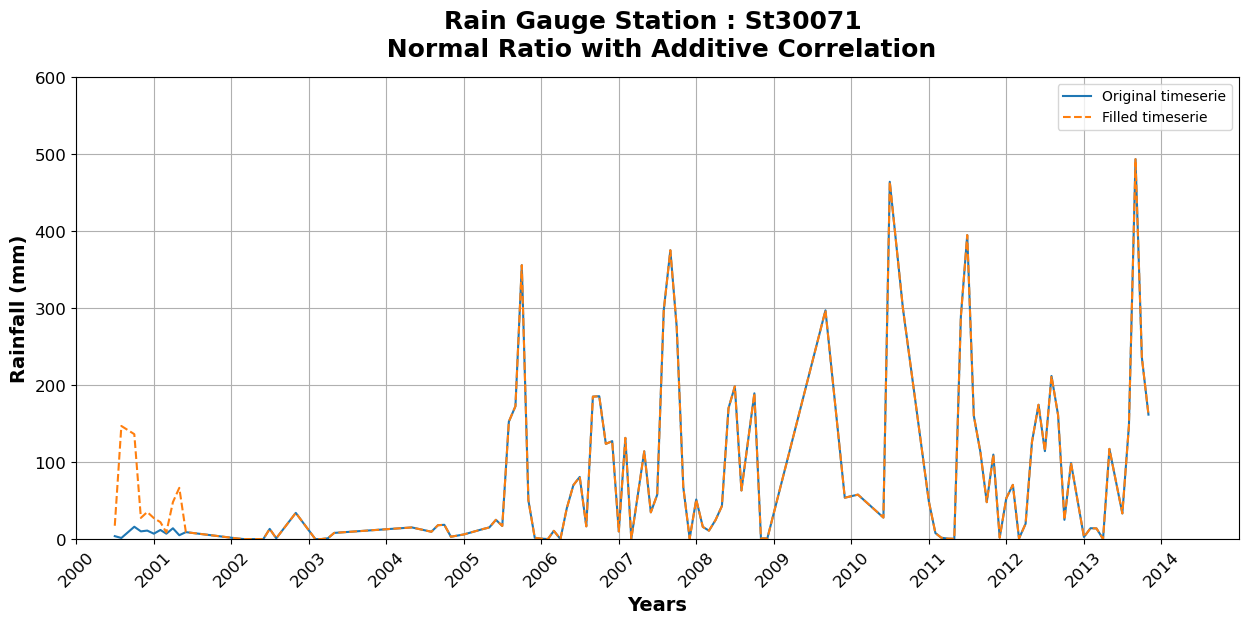

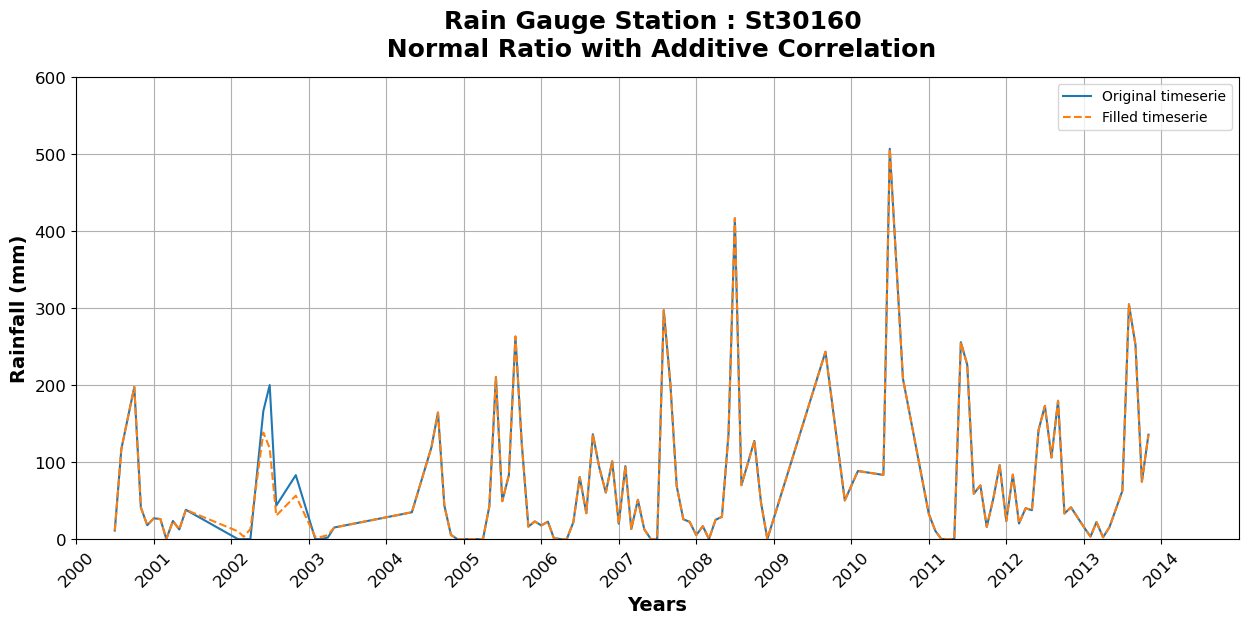

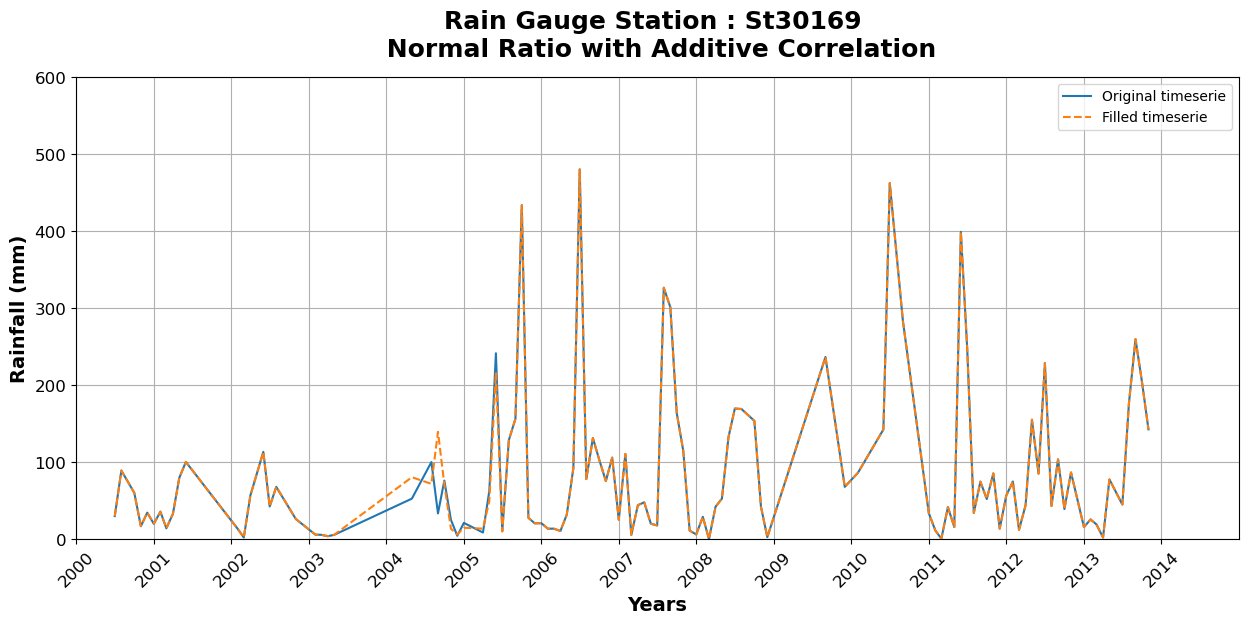

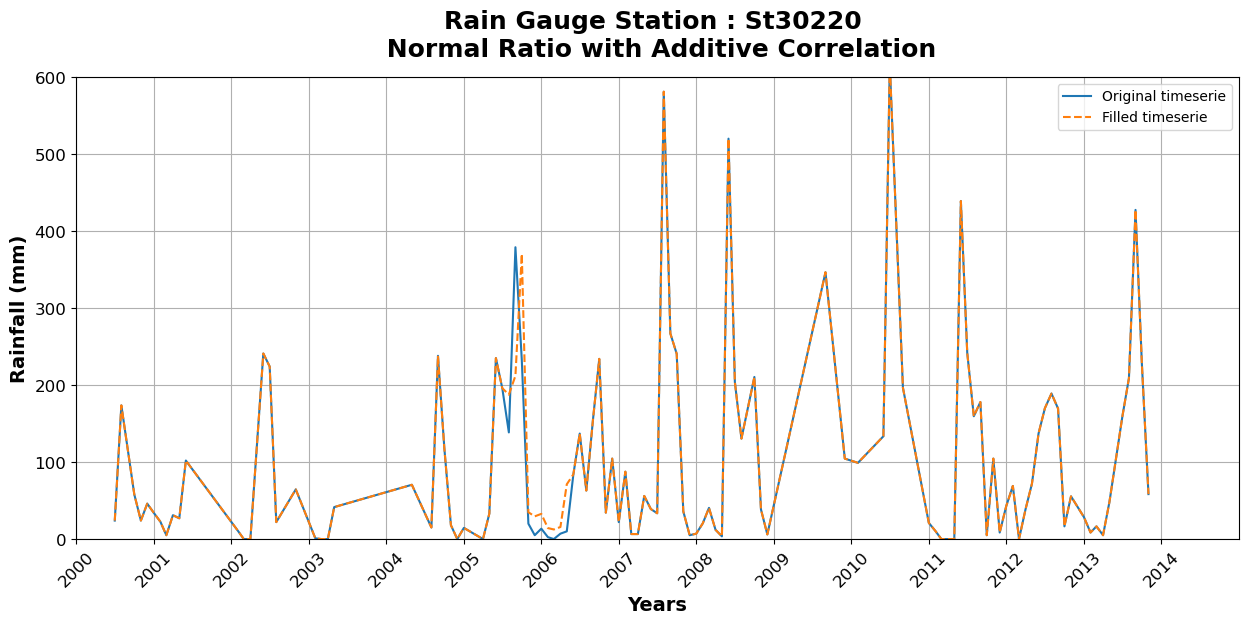

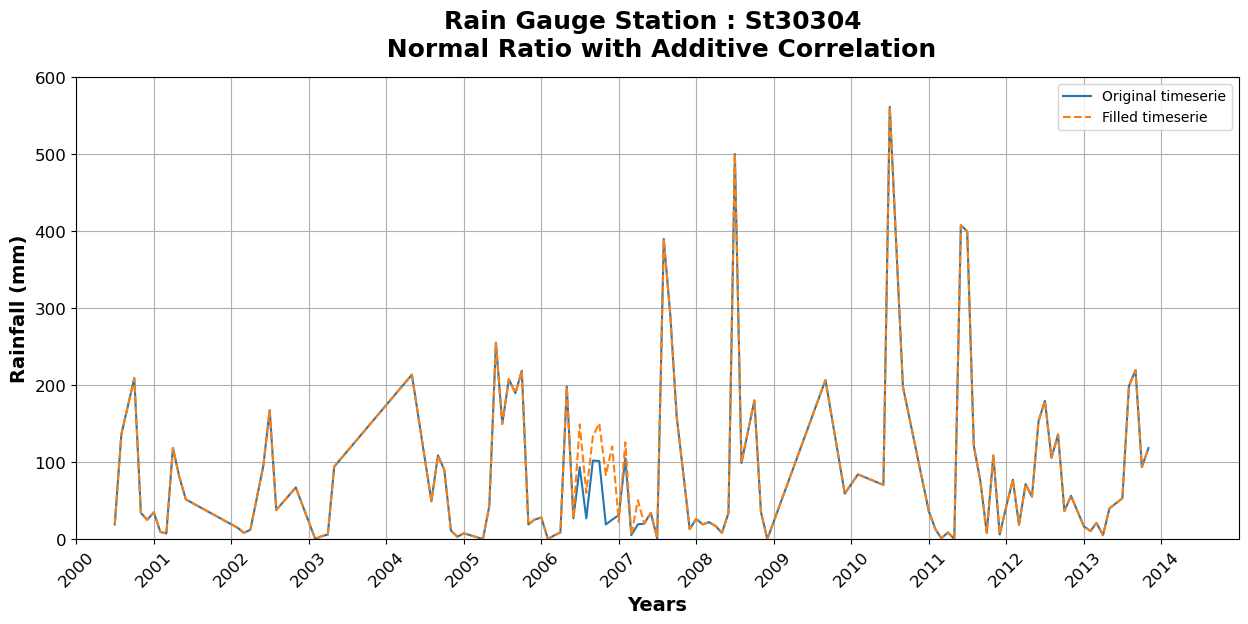

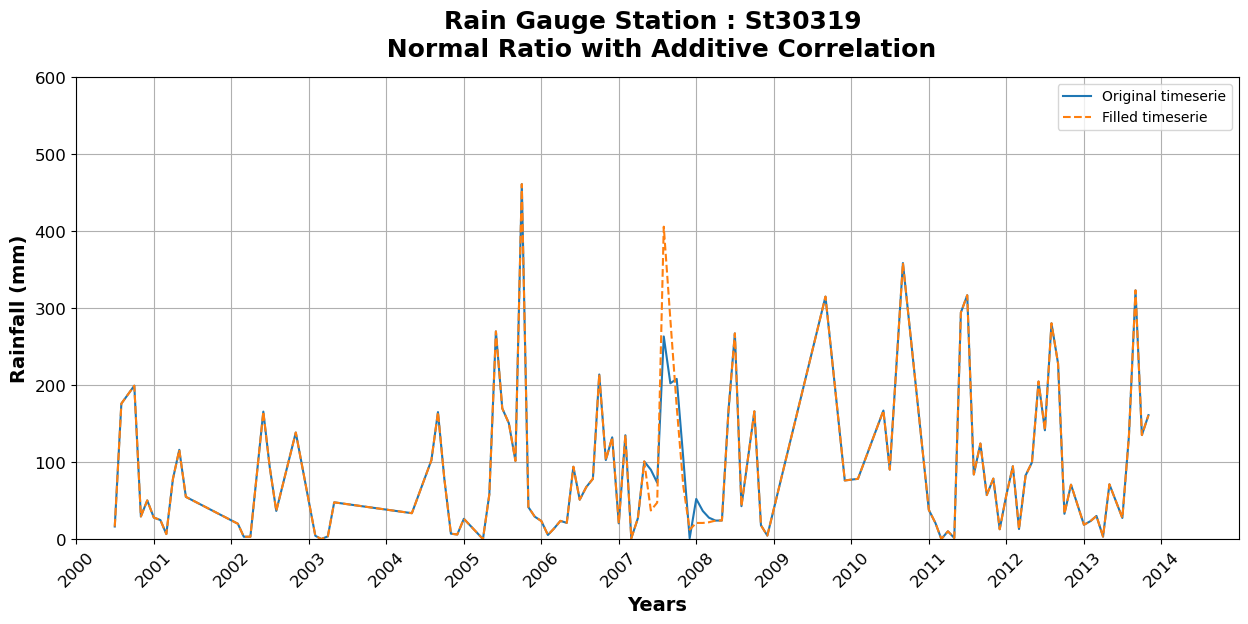

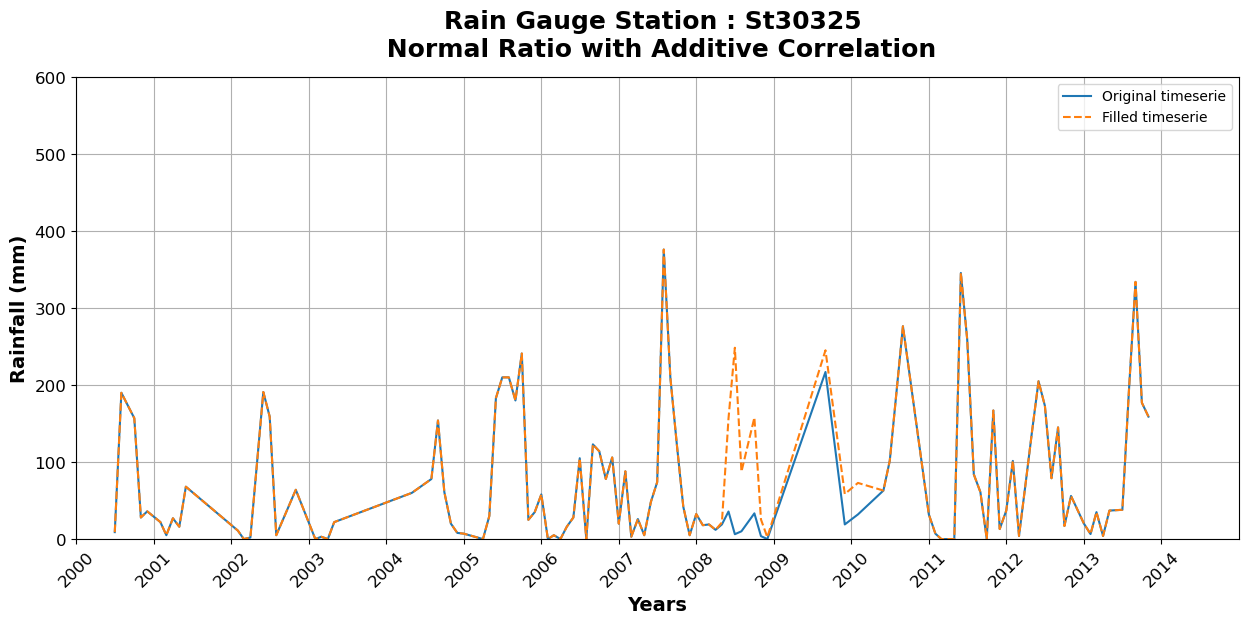

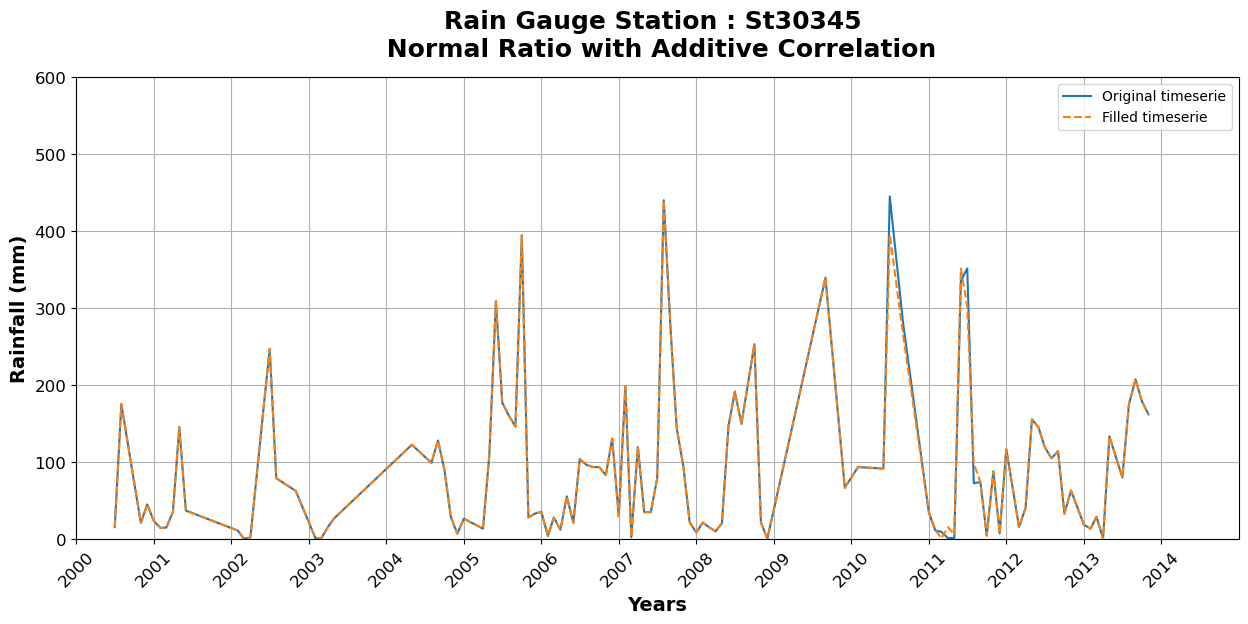

In [71]:
#Graficando las dos lines
Outpath_Fig = pathOutput
for Est in Estaciones:
    #
    plt.figure(figsize=(15,6))
    plt.plot(df_2doPeriodPCP.index,df_2doPeriodPCP_copy[Est],label='Original timeserie')
    plt.plot(Dataset_NRAC.index,Dataset_NRAC[Est], label='Filled timeserie',linestyle='--')

    plt.ylim(0,600)
    plt.yticks(ticks = np.arange(0,700,100), fontsize=12)
    plt.xlim(pd.to_datetime('2000-01-01'),pd.to_datetime('2014-12-31'))
     
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y')) 

    plt.xticks(rotation=45,fontsize=12)
    plt.xlabel('Years',fontsize=14,fontweight='bold')
    plt.ylabel('Rainfall (mm)',fontsize=14,fontweight='bold')
    plt.title(f'Rain Gauge Station : {Est} \n Normal Ratio with Additive Correlation', fontsize=18, fontweight='bold',pad=15)
    plt.legend()
    plt.grid(True)
    
    plt.savefig(f'{Outpath_Fig}/{Est}_NRAC_x.png', dpi=300, bbox_inches='tight', facecolor='w')

    #plt.show()

    print(f'LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: {Outpath_Fig}')
    

In [51]:
# Funcion graficas con zoom  
def GrafEstZoom (df_original, df_filled, ListEst,limits_zoom, dateini_zoom, datefin_zoom,method,acronMethod, pathsave ):

    
    for Est in ListEst:
        fig, ax = plt.subplots(figsize=(15,6))
        ax.plot(df_original.index,df_original[Est],label='Timeseries Original')
        ax.plot(df_filled.index,df_filled[Est], label='Timeseries Filled',linestyle='--')

        ax.set_ylim(0,600)
        ax.set_yticks(np.arange(0,700,100))
        ax.tick_params(axis='y',labelsize=16)
        ax.set_xlim(pd.to_datetime('2000-01-01'),pd.to_datetime('2014-12-31'))

        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) 

        ax.tick_params(axis='x',rotation=45,labelsize=16)
        ax.set_xlabel('Years',fontsize=20,fontweight='bold')
        ax.set_ylabel('Rainfall (mm)',fontsize=20,fontweight='bold')
        ax.set_title(f'Rain Gauge Station : {Est} \n {method}', fontsize=24, fontweight='bold',pad=15)
        ax.legend()
        ax.grid(True)


        #zoom a la seccion
        axins = inset_axes(ax, width=3.0, height=2.5,loc='upper left', bbox_to_anchor=(0.06,0.97), bbox_transform=ax.transAxes)
        axins.plot(df_original.index, df_original[Est], label='Timeseries Original')
        axins.plot(df_filled.index, df_filled[Est], label='Timeseries filled', linestyle='--')

        axins.set_xlim(pd.to_datetime(dateini_zoom[Est]), pd.to_datetime(datefin_zoom[Est]))
        axins.set_ylim(0,limits_zoom[Est])
        axins.xaxis.set_major_locator(mdates.YearLocator())
        axins.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        axins.yaxis.set_major_locator(plt.MultipleLocator(50))

        for label in axins.get_xticklabels():
            label.set_fontweight('bold')
            label.set_fontsize(14)

        for label in axins.get_yticklabels():
            label.set_fontweight('bold')
            label.set_fontsize(14)



        
        axins.grid(True)
       

        for spine in axins.spines.values():
            spine.set_edgecolor('gray')
            spine.set_linewidth(3)


        mark_inset(ax, axins, loc1=3, loc2=1, fc='none', ec='0.5',linestyle='--')

        plt.savefig(f'{pathsave}/{Est}_zoom_{acronMethod}.png', format='png', dpi=300, bbox_inches='tight', facecolor='w')

    return print('Realizado')



In [55]:
dateini_zoom={
    'St30071':'2000-01-01',
    'St30160':'2002-01-01',
    'St30169':'2003-01-01',
    'St30220':'2005-01-01',
    'St30304':'2006-01-01',
    'St30319':'2007-01-01',
    'St30325':'2008-01-01',
    'St30345':'2010-01-01'
    }
datefin_zoom={
    'St30071':'2002-01-01',
    'St30160':'2004-01-01',
    'St30169':'2005-01-01',
    'St30220':'2007-01-01',
    'St30304':'2008-01-01',
    'St30319':'2009-01-01',
    'St30325':'2011-01-01',
    'St30345':'2012-01-01'
    }

limts = {
    'St30071':150,
    'St30160':200,
    'St30169':150,
    'St30220':400,
    'St30304':200,
    'St30319':450,
    'St30325':250,
    'St30345':450
}

metodoNRAC = 'Normal Ratio with Additive Correlation'
pathNRAC_fin = pathOutput
acronimo = 'NRAC'

Realizado


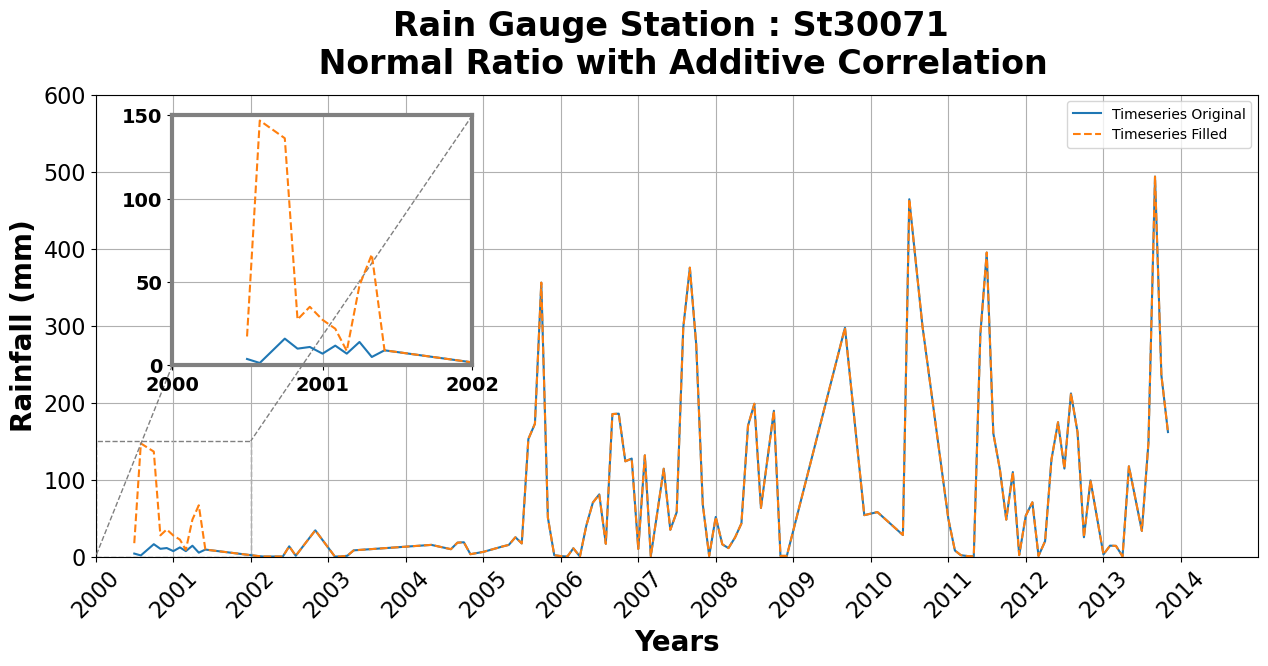

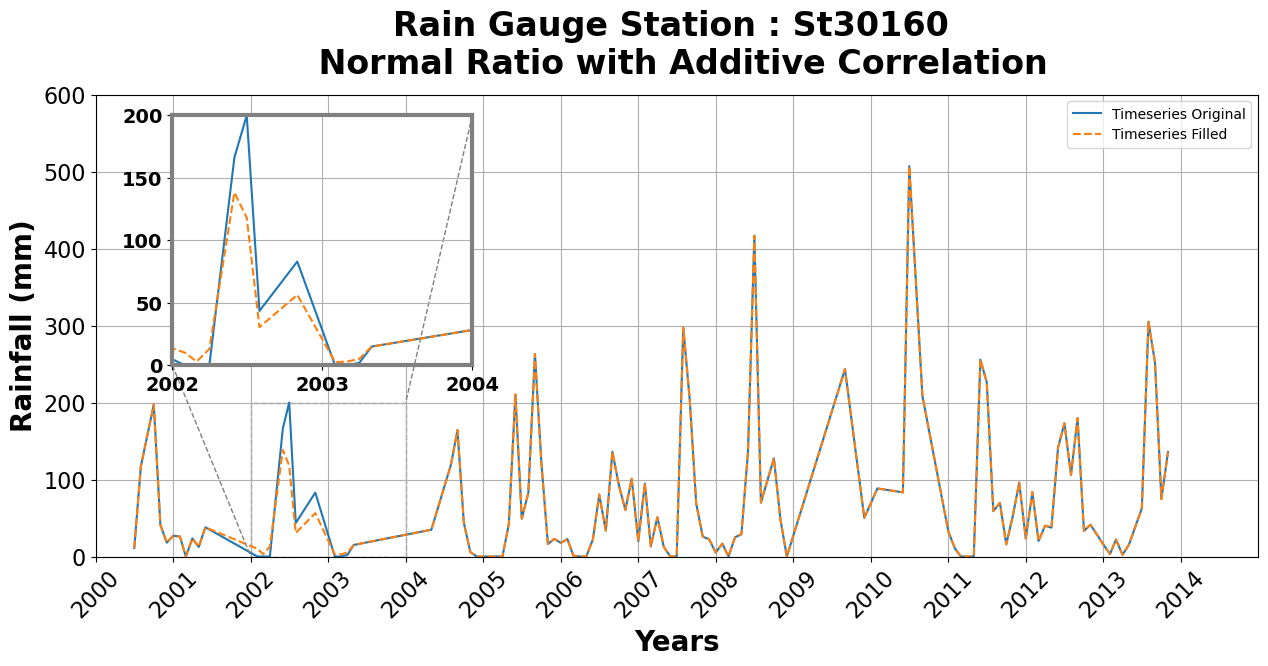

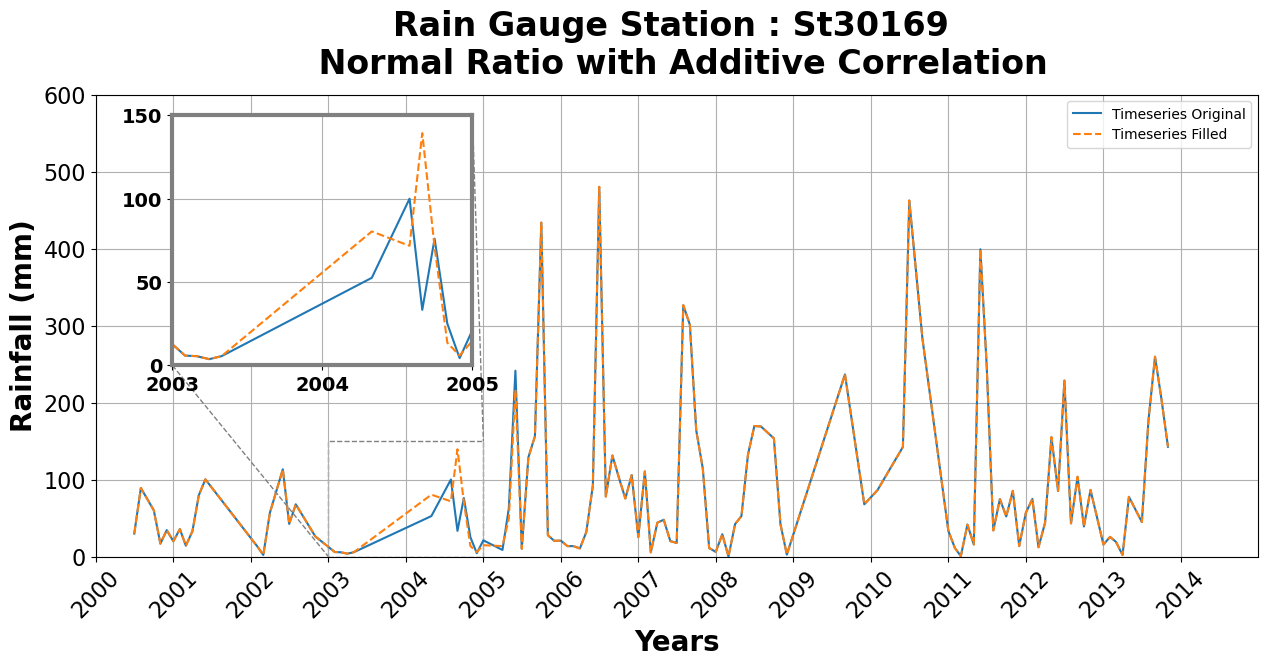

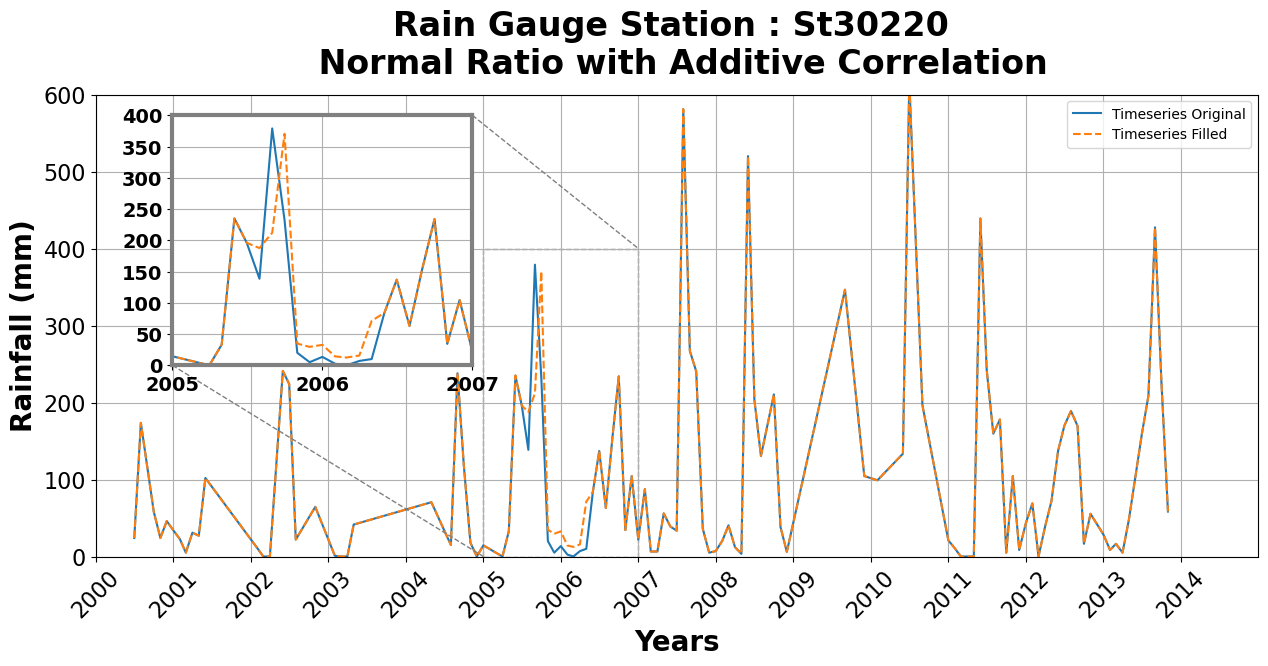

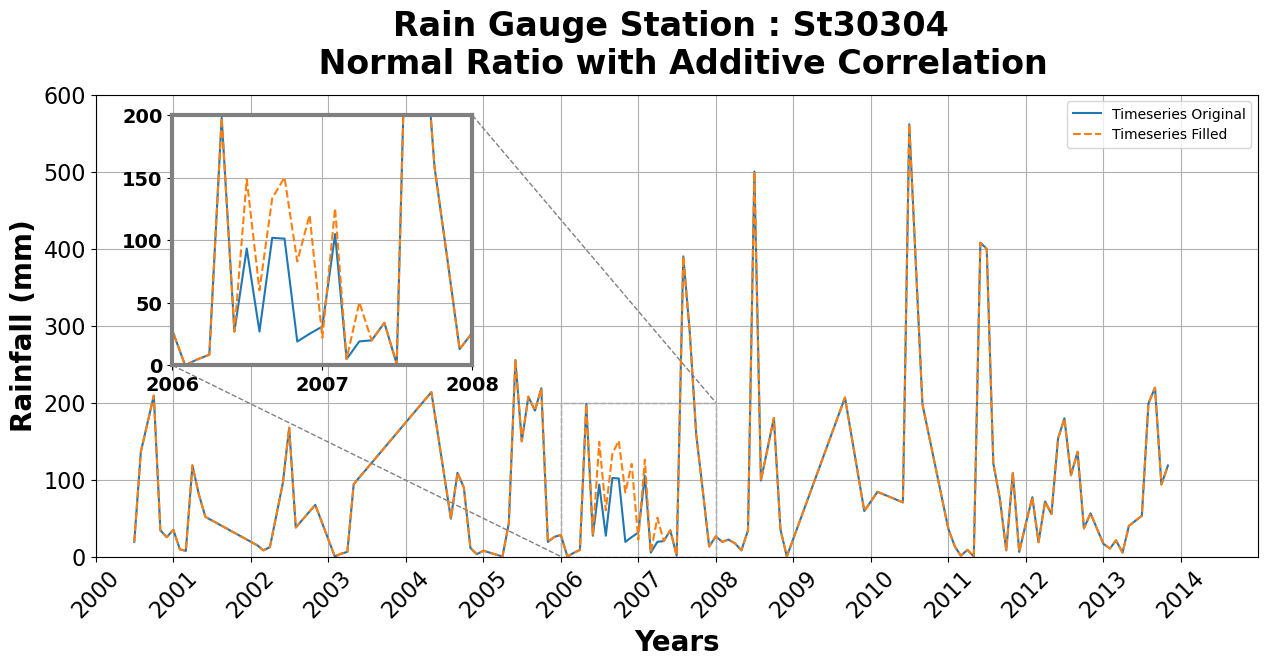

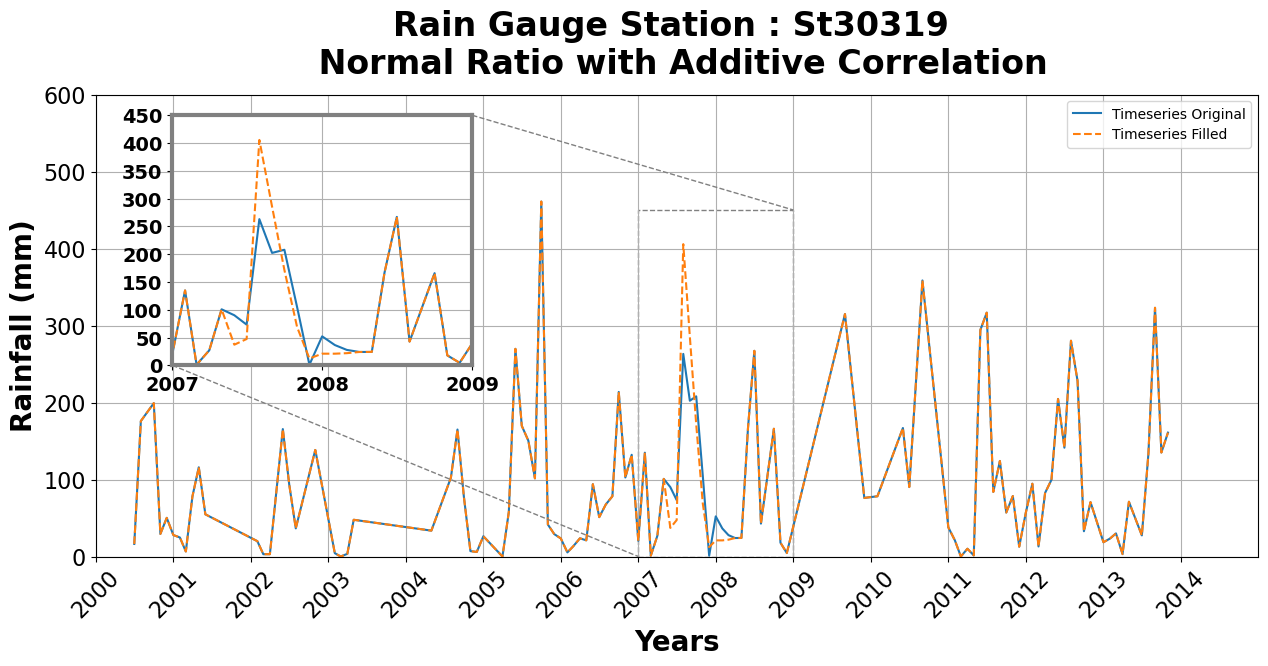

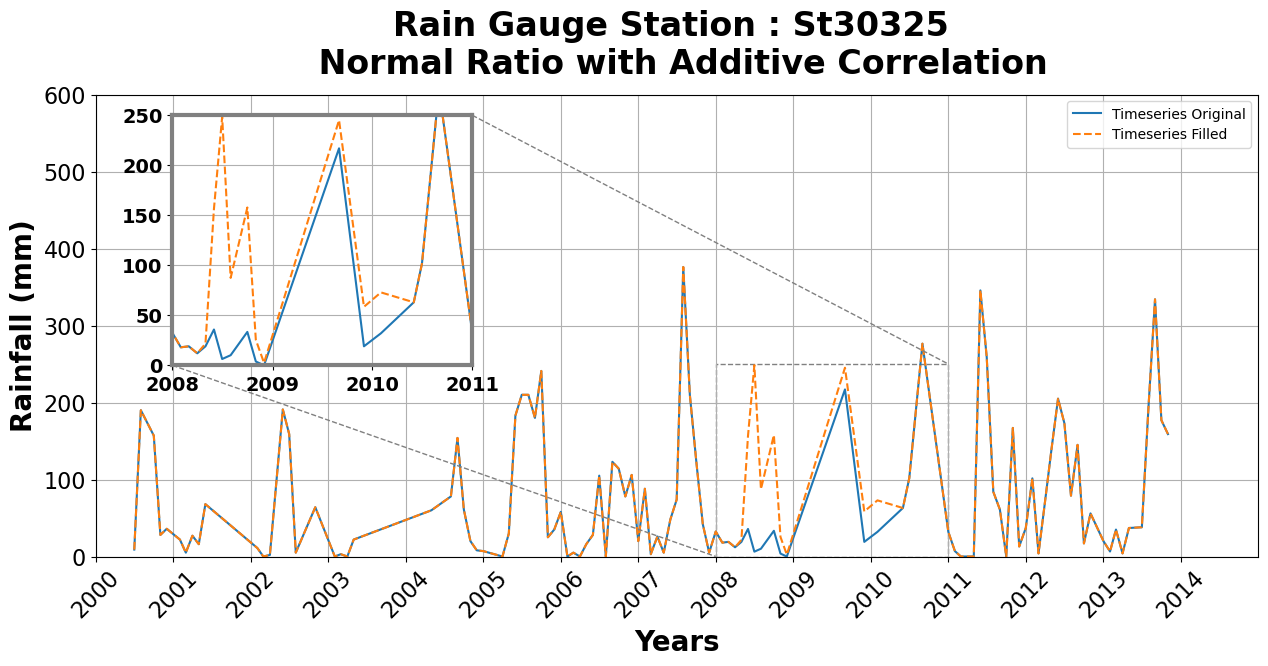

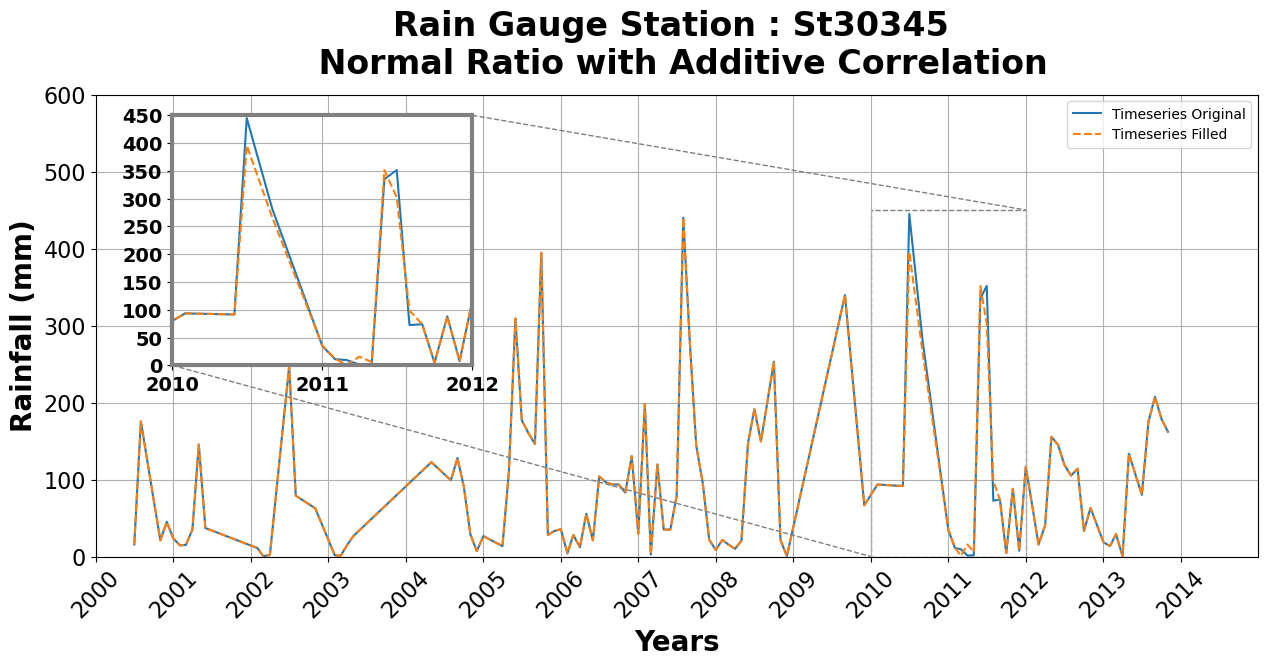

In [56]:
#Prueba funcion
GrafEstZoom(df_2doPeriodPCP_copy,Dataset_NRAC,Estaciones,limts,dateini_zoom,datefin_zoom,metodoNRAC,acronimo,pathNRAC_fin)

In [57]:
# Funcion solo con seccion de zoom  
def GrafZoom (df_original, df_filled, ListEst,limits_zoom, dateini_zoom, datefin_zoom,method,acronMethod, pathsave ):

    
    for Est in ListEst:
        fig, ax = plt.subplots(figsize=(6,6))
        ax.plot(df_original.index,df_original[Est],label='Timeseries Original')
        ax.plot(df_filled.index,df_filled[Est], label='Timeseries Filled',linestyle='--')

        ax.set_ylim(0,limits_zoom[Est])
        ax.set_yticks(np.arange(0,limits_zoom[Est]+50,50))
        ax.tick_params(axis='y',labelsize=16)
        ax.set_xlim(pd.to_datetime(dateini_zoom[Est]),pd.to_datetime(datefin_zoom[Est]))

        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) 

        ax.tick_params(axis='x', labelsize=16)
        ax.set_xlabel('Years',fontsize=20,fontweight='bold')
        ax.set_ylabel('Rainfall (mm)',fontsize=20,fontweight='bold')
        ax.set_title(f'{Est} \n {method}', fontsize=24, fontweight='bold',pad=15)
        ax.legend()
        ax.grid(True)


       

        plt.savefig(f'{pathsave}/{Est}_{acronMethod}.png', format='png', dpi=300, bbox_inches='tight', facecolor='w')

    return print('Realizado')


In [58]:
metodoRNCA = 'NRAC'
pathRNCA_fin = pathOutput
acronimoNRCA = 'NRAC'

Realizado


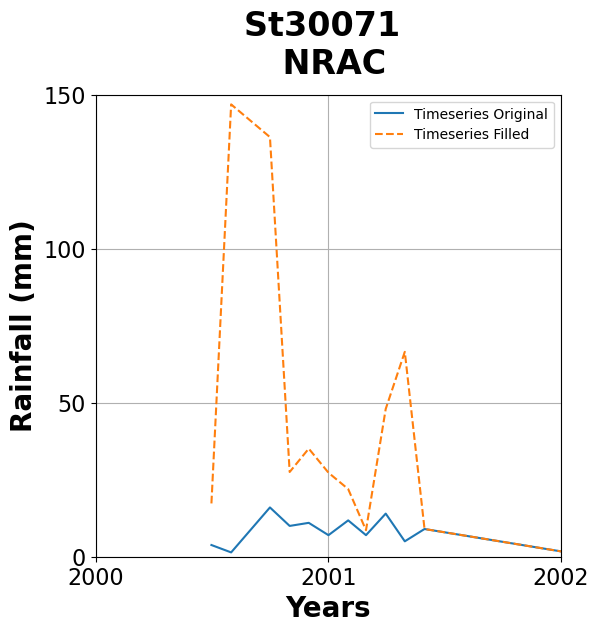

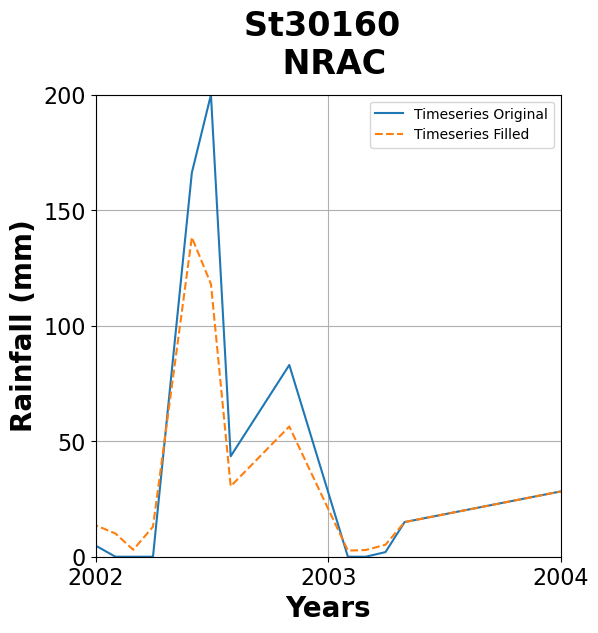

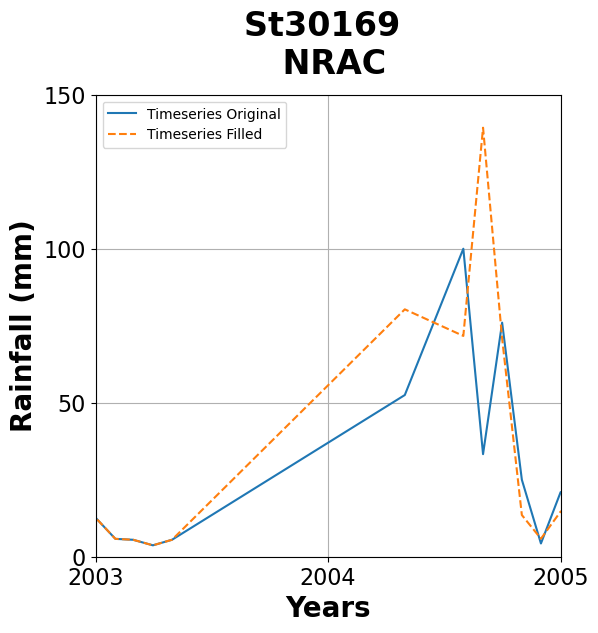

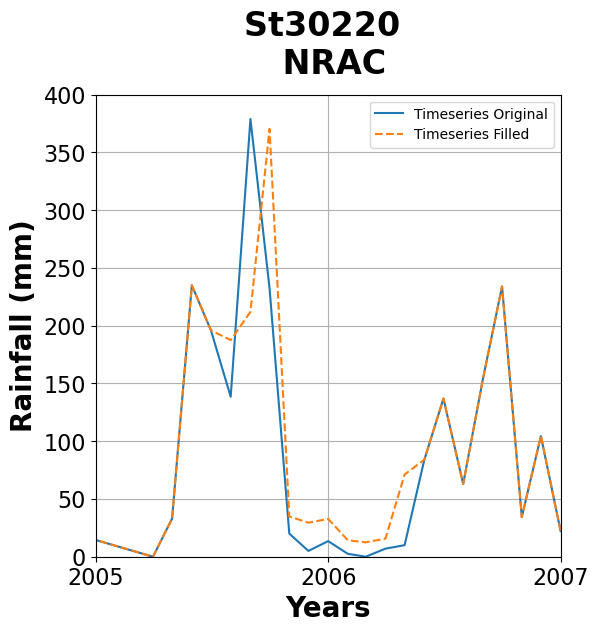

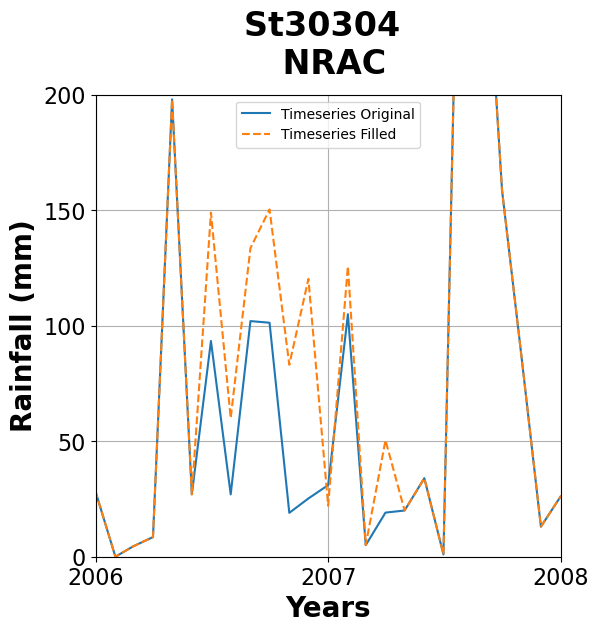

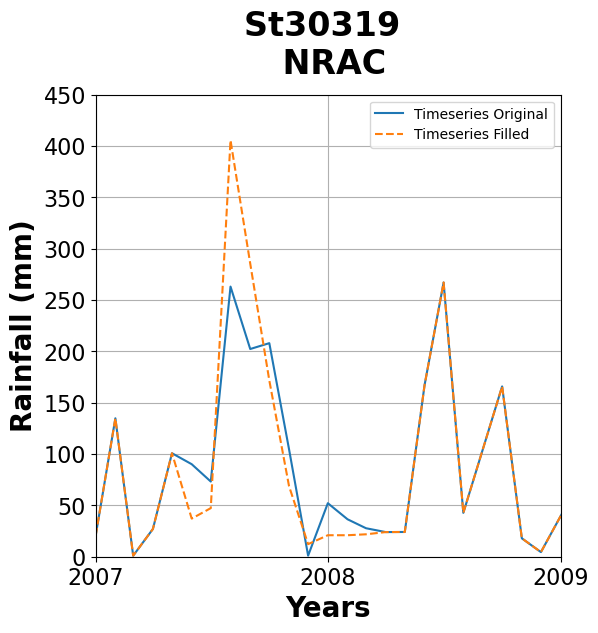

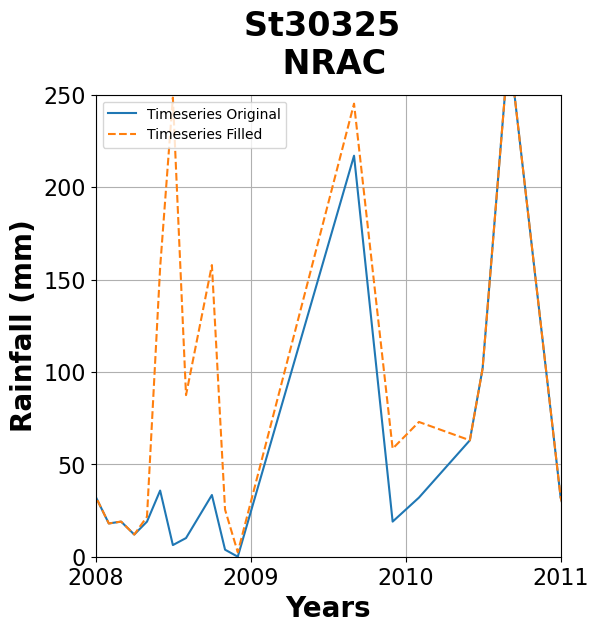

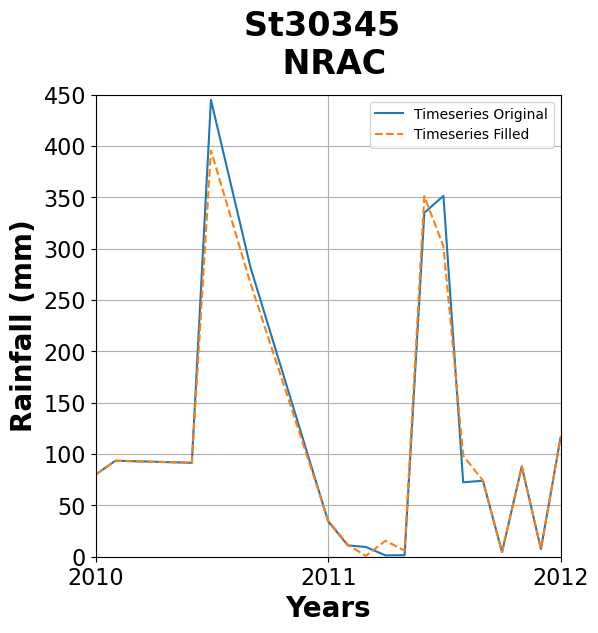

In [59]:
#Prueba funcion
GrafZoom(df_2doPeriodPCP_copy,Dataset_NRAC,Estaciones,limts,dateini_zoom,datefin_zoom,metodoRNCA,acronimoNRCA,pathRNCA_fin)

### Metrics (NRAC)

In [60]:
MetricsNRAC = Calculadora_metrics(df_2doPeriodPCP_copy,Dataset_NRAC)
MetricsNRAC

,R^2,RMSE,MAE,r
St30071,0.97,19.40,4.00,0.98
St30160,0.99,8.80,1.65,1.00
St30169,0.99,11.11,2.05,0.99
St30220,0.97,22.08,4.52,0.98
St30304,0.98,14.08,3.48,0.99
St30319,0.96,17.60,3.94,0.98
St30325,0.88,29.76,6.25,0.94
St30345,0.99,7.52,1.66,1.00


# Normal Ratio

### Function and Aplication

In [62]:
def CalcDatosRadioNormal (rowMR,prom_mr,i,j):
    Ponderacion = 0
    n=0

    rowMR_val = rowMR.values
    promMR_val = prom_mr.values

    for j2 in range(len(rowMR_val)):
        if MissingData.iloc[i,j2]==0:
            Ponderacion+=(promMR_val[j]/promMR_val[j2])*rowMR_val[j2]
            n+=1


    return round(((1/n)*Ponderacion),2)


In [63]:
# APLICANDO EL METODO DEL RADIO NORMAL
Dataset_NR = dataFile   # Dataset para el metodo del radio

#Convierto los datos existentes en flotantes y los inexistentes se quedan tal cual.
Dataset_NR=Dataset_NR.apply(pd.to_numeric, errors='coerce')

tot_Est = Dataset_NR.shape[1]

sum_NR= Dataset_NR.sum()
numtot_NR = Dataset_NR.count()
prom_NR = sum_NR/numtot_NR

# Identificó los datos faltantes y en caso de encontrar alguno, y solicito el cálculo del promedio ponderado para ese elemento.
for i in range(len(Dataset_NR)):
    for j in range(len(Dataset_NR.columns)):
        if pd.isna(Dataset_NR.iloc[i,j]):
            Dataset_NR.iloc[i,j]=CalcDatosRadioNormal(Dataset_NR.iloc[i, :],prom_NR,i,j)


Dataset_NR.to_excel(f'{pathOutput}\PruebaRelleno_MRadio.xlsx')

Dataset_NR


Stations,St30071,St30160,St30169,St30220,St30304,St30319,St30325,St30345
date,,,,,,,,
2000-07-01,17.09,11.0,29.8,24.0,19.10,16.30,9.0,15.5
2000-08-01,148.40,117.0,89.0,173.6,136.00,175.90,190.0,175.5
2000-10-01,136.91,197.5,60.0,58.0,209.00,199.20,157.0,72.5
2000-11-01,27.64,41.0,16.7,24.0,34.00,29.30,28.0,21.0
2000-12-01,35.21,18.0,34.3,46.0,25.00,50.20,36.0,45.0
...,...,...,...,...,...,...,...,...
2013-07-01,33.30,62.6,44.8,159.1,52.92,27.40,38.0,80.0
2013-08-01,147.50,304.9,176.5,209.0,198.72,134.00,193.0,175.0
2013-09-01,493.40,251.8,259.5,427.5,219.41,323.01,334.0,207.5


### Graphs (NR)

LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCode_Comprobacion
LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: D:\UAT_Doc\Cap_libro_springer_2025\2.Envio_CorreccionesAbril\VSCo

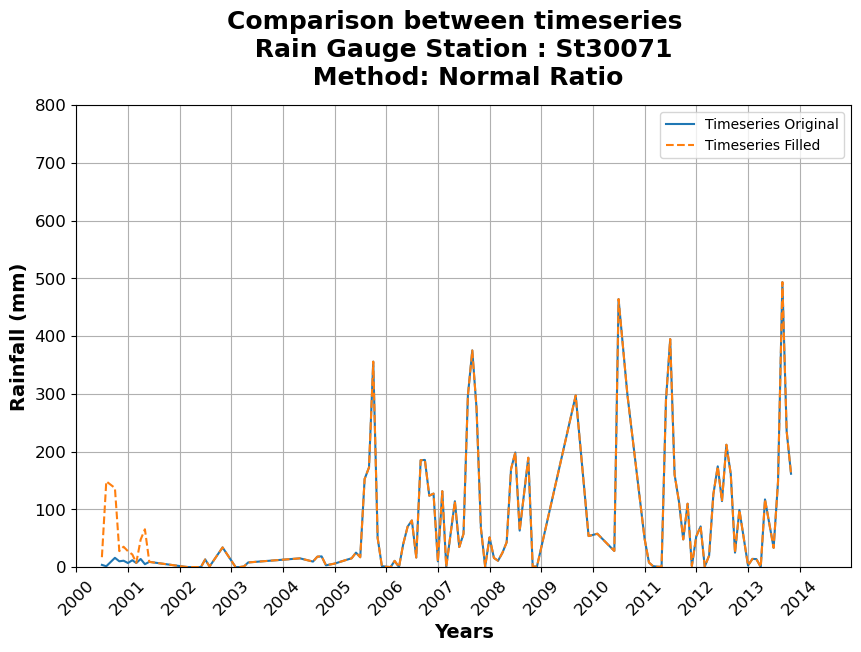

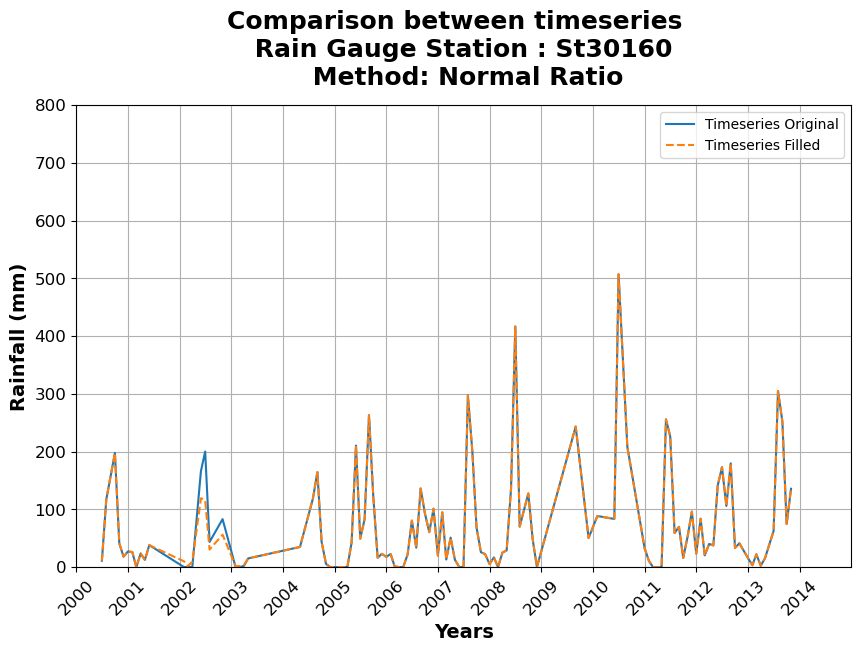

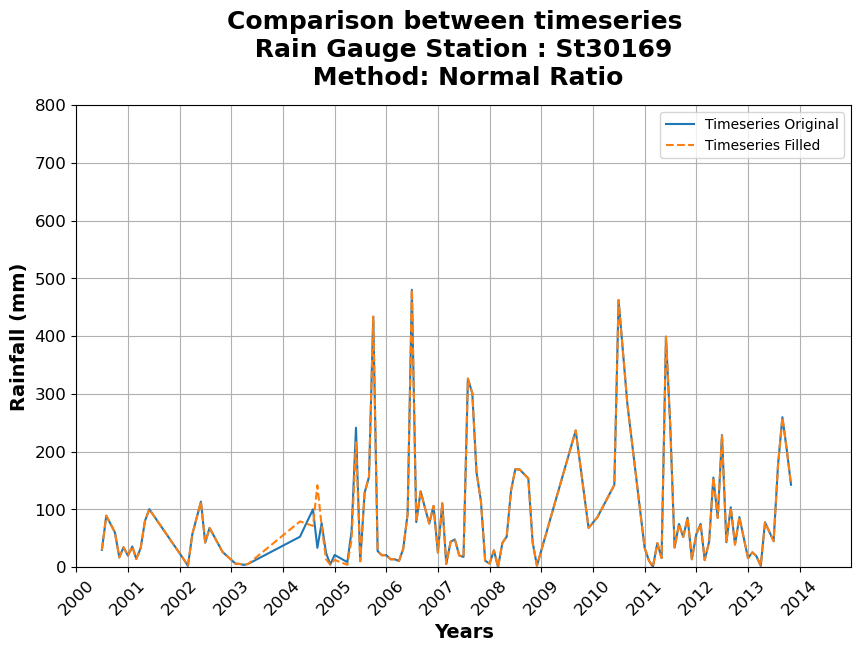

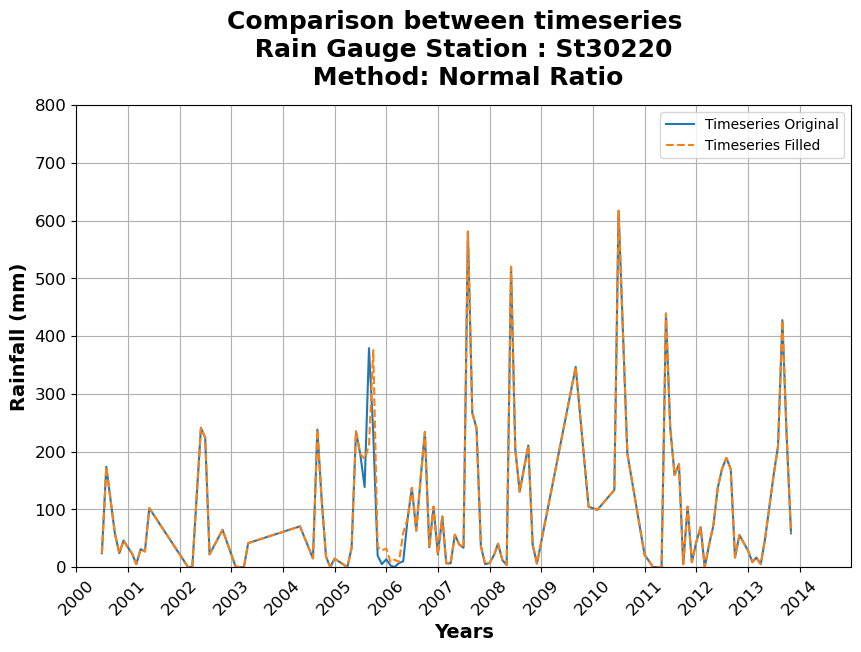

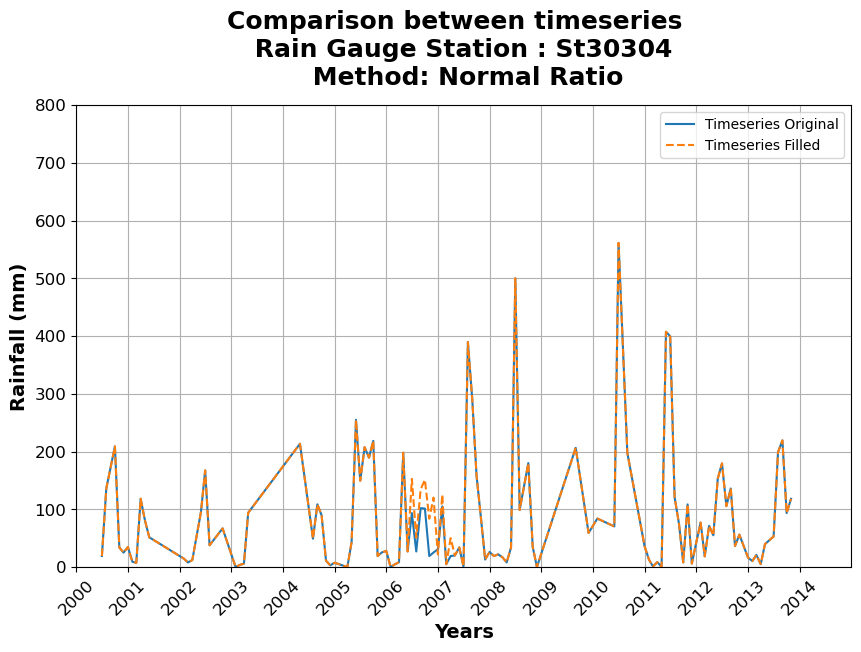

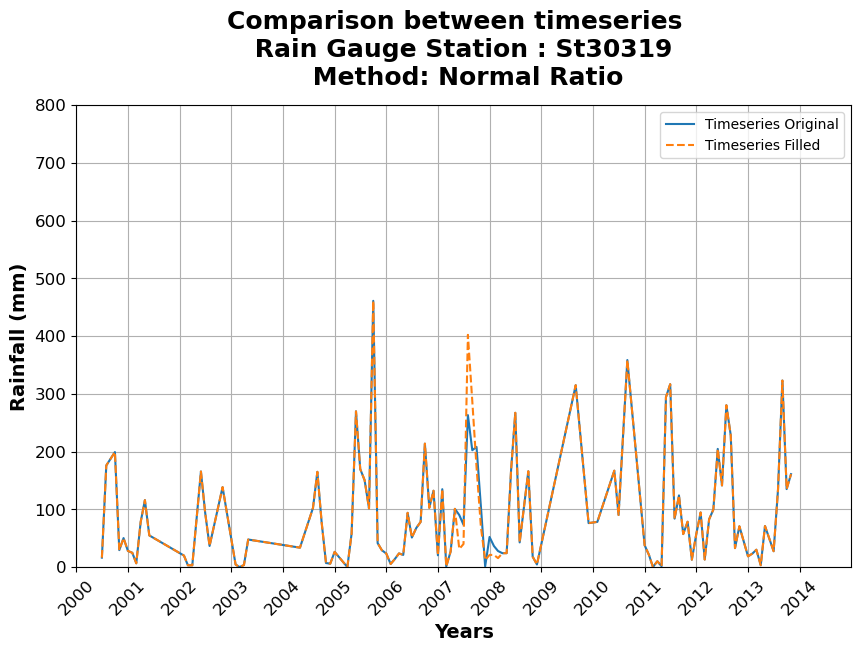

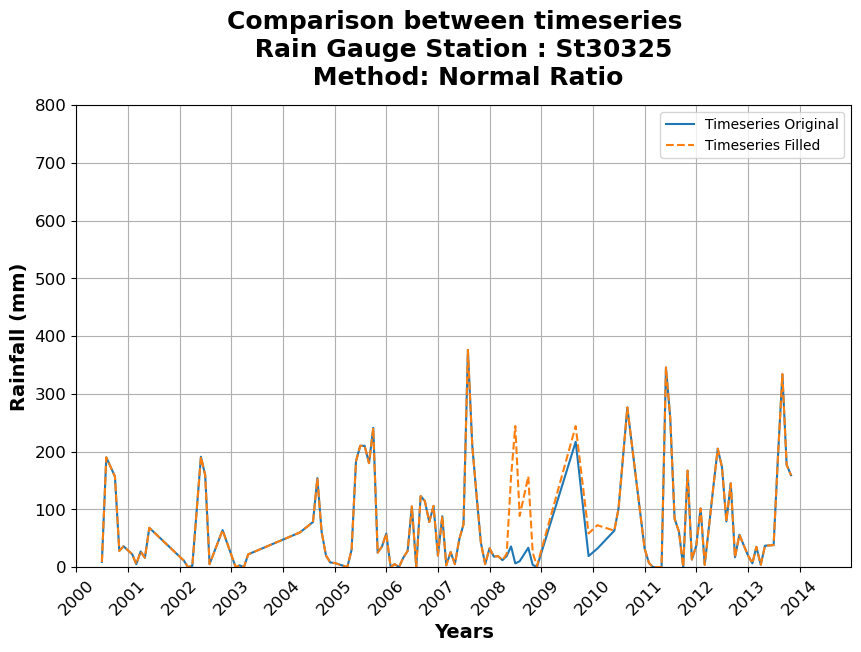

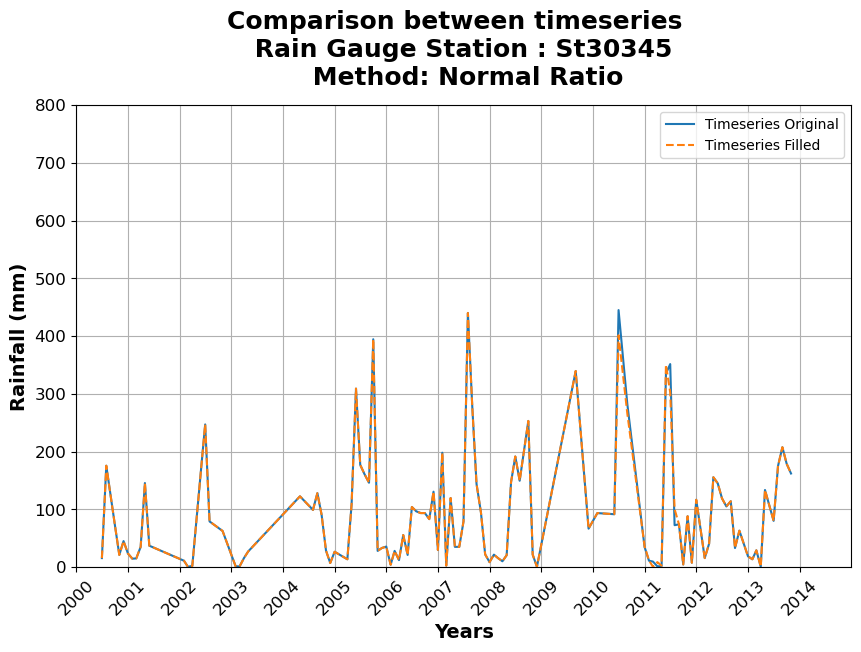

In [65]:
#Graficando las dos lines
for Est in Estaciones:
    #
    plt.figure(figsize=(10,6))
    plt.plot(df_2doPeriodPCP.index,df_2doPeriodPCP_copy[Est],label='Timeseries Original')
    plt.plot(Dataset_NR.index,Dataset_NR[Est], label='Timeseries Filled',linestyle='--')

    plt.ylim(0,800)
    plt.yticks(ticks = np.arange(0,900,100), fontsize=12)
    plt.xlim(pd.to_datetime('2000-01-01'),pd.to_datetime('2014-12-31'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45,fontsize=12)
    plt.xlabel('Years',fontsize=14,fontweight='bold')
    plt.ylabel('Rainfall (mm)',fontsize=14,fontweight='bold')
 
    plt.title(f'Comparison between timeseries  \n Rain Gauge Station : {Est} \n Method: Normal Ratio', fontsize=18, fontweight='bold',pad=15)
    plt.legend()
    plt.grid(True)
    
    plt.savefig(f'{Outpath_Fig}/{Est}_NR.png', dpi=300, bbox_inches='tight', facecolor='w')

    #plt.show()

    print(f'LAS FIGURAS SE HAN GUARDADO CORRECTAMENTE EN: {Outpath_Fig}')
    

In [66]:
pathNR_fin = pathOutput
acronim = 'NR'
metodoNR = 'Normal Ratio'

Realizado


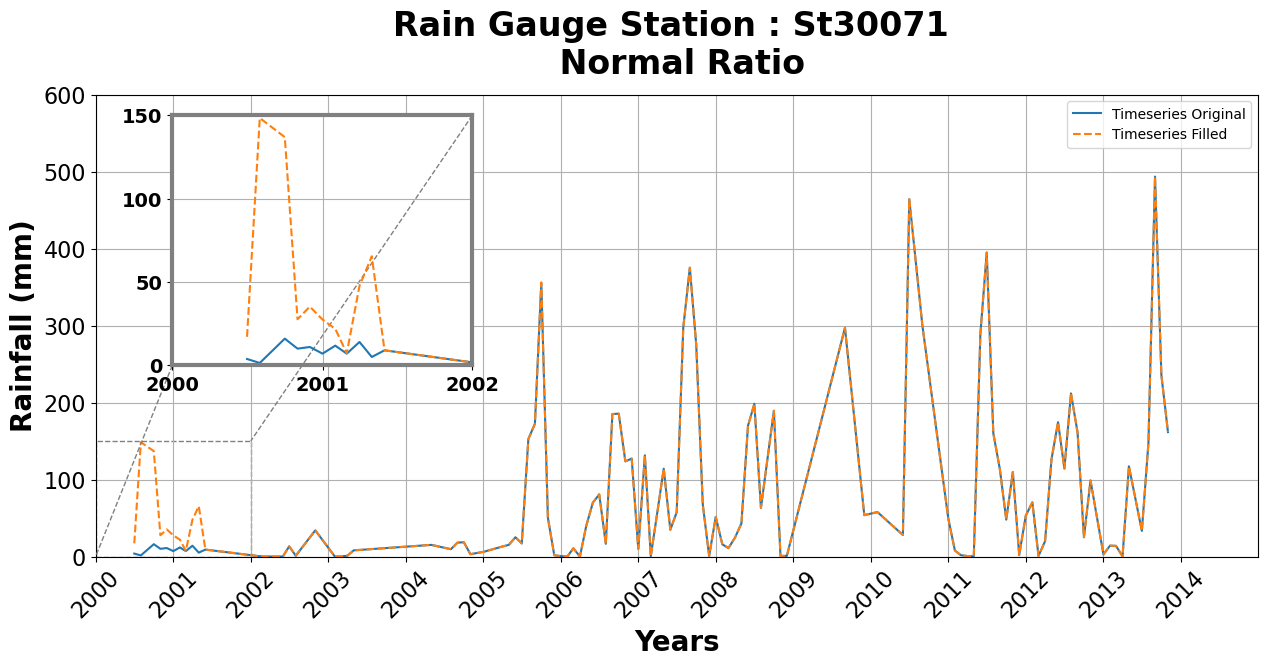

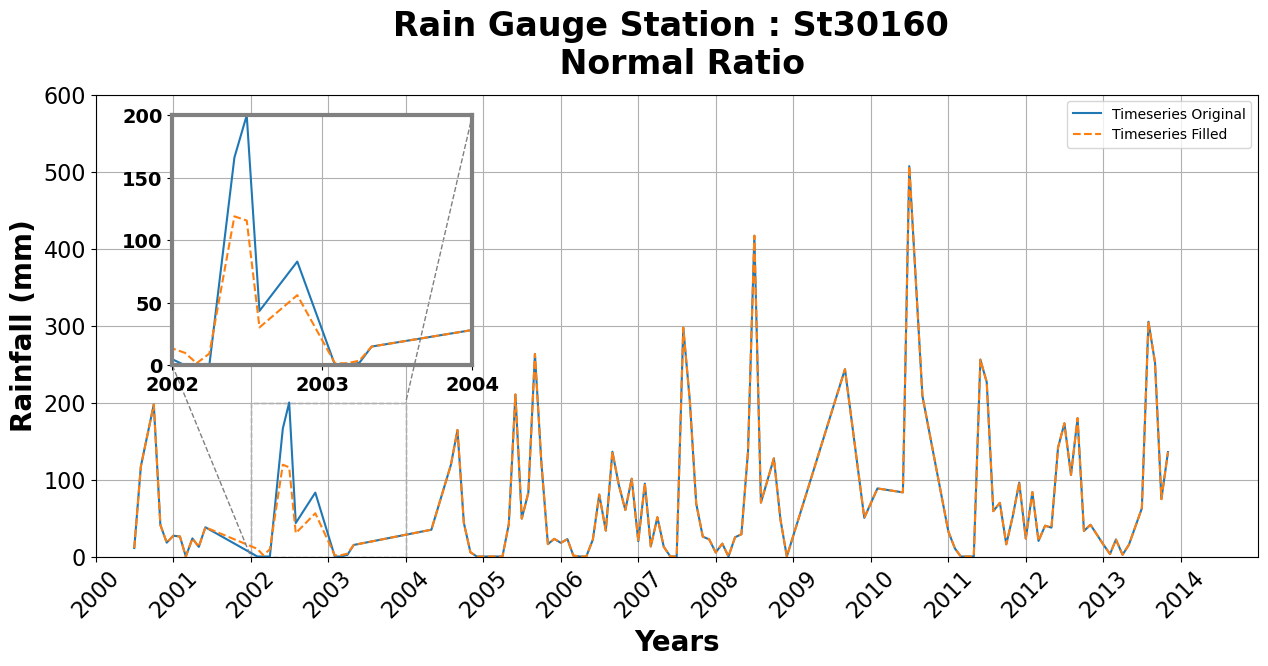

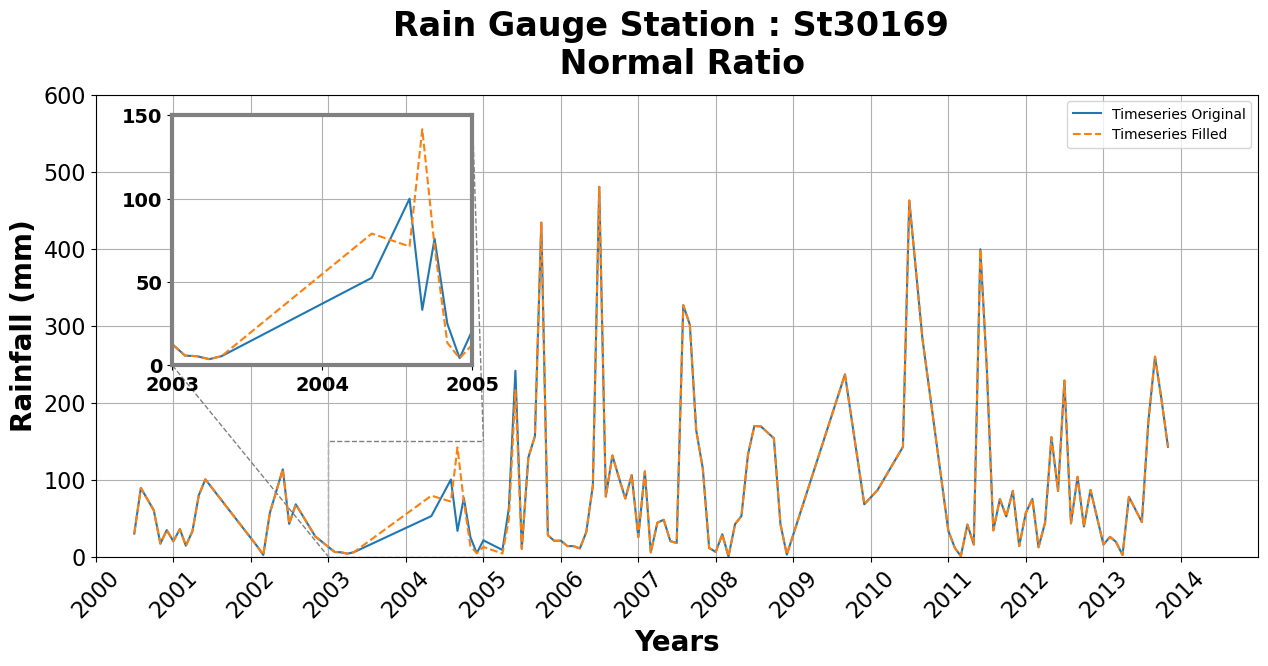

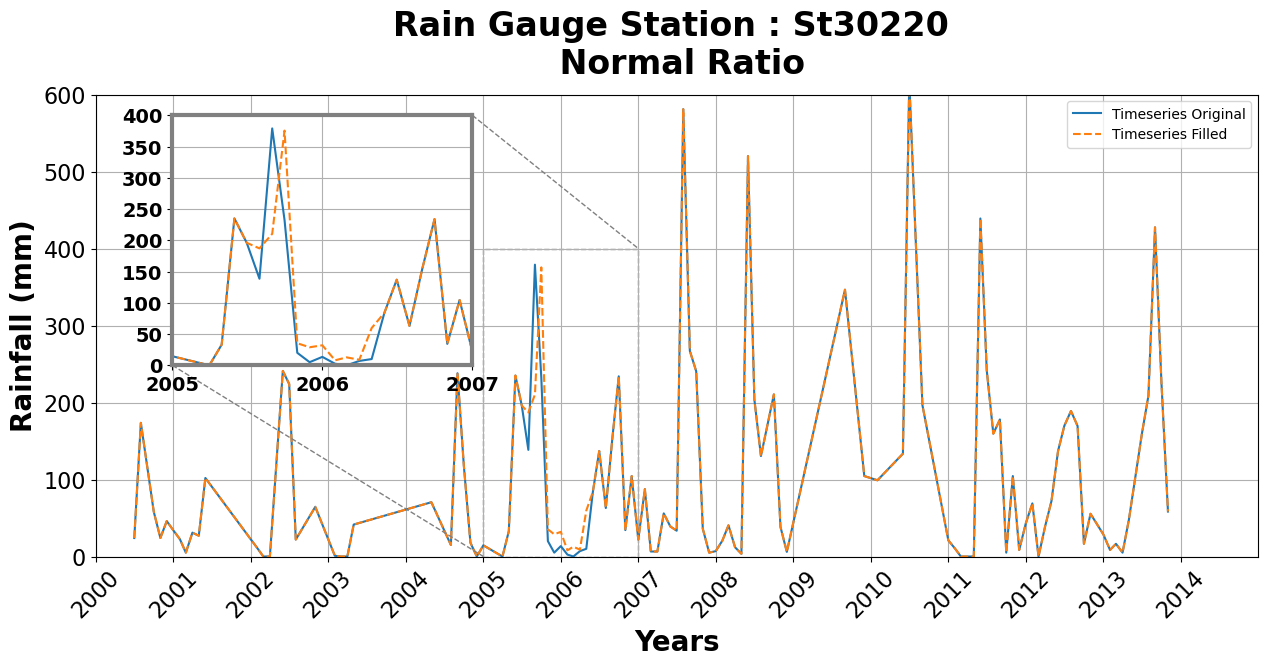

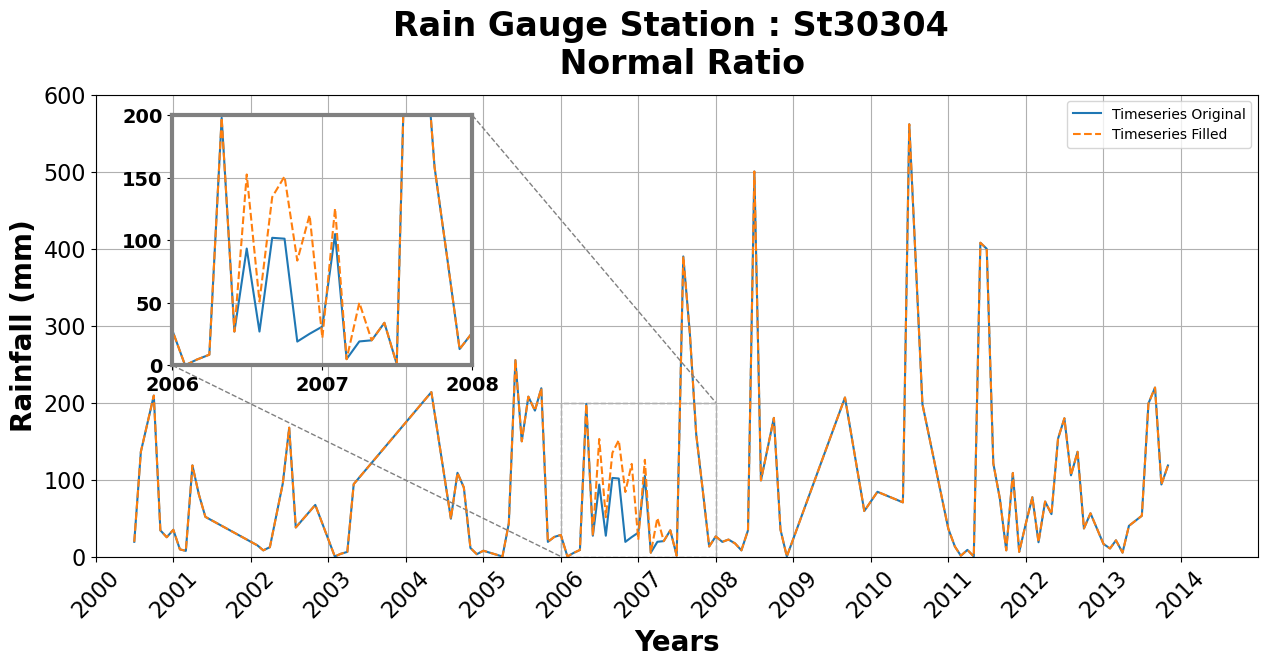

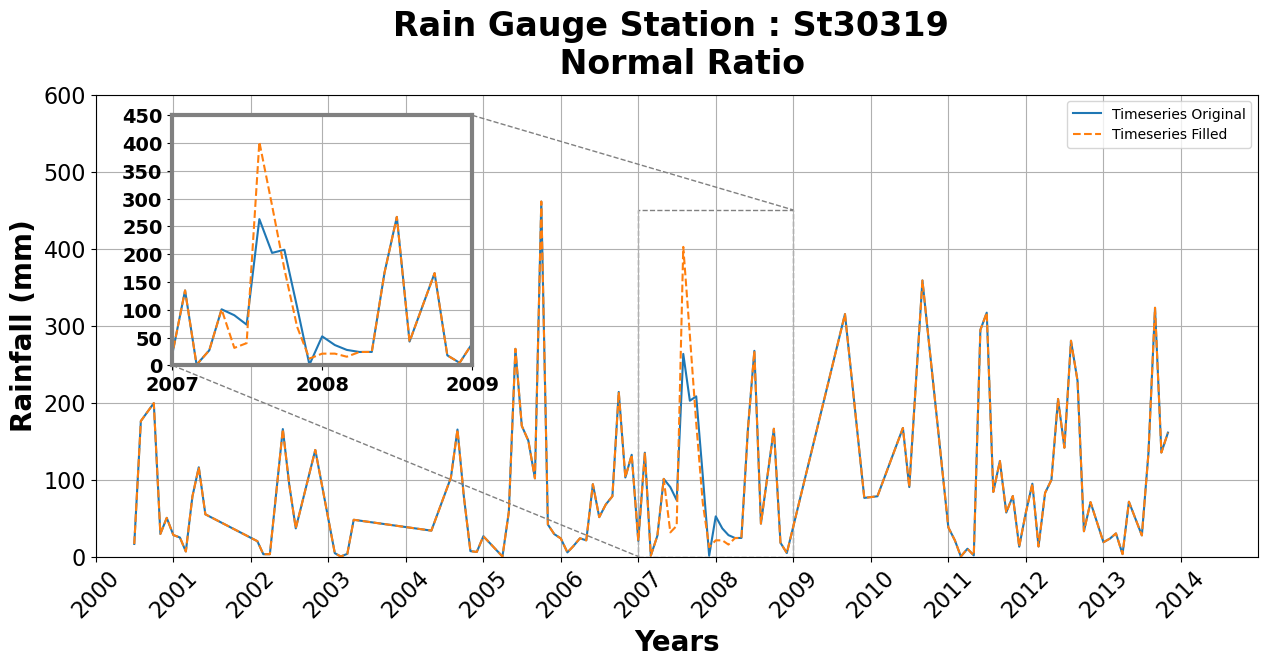

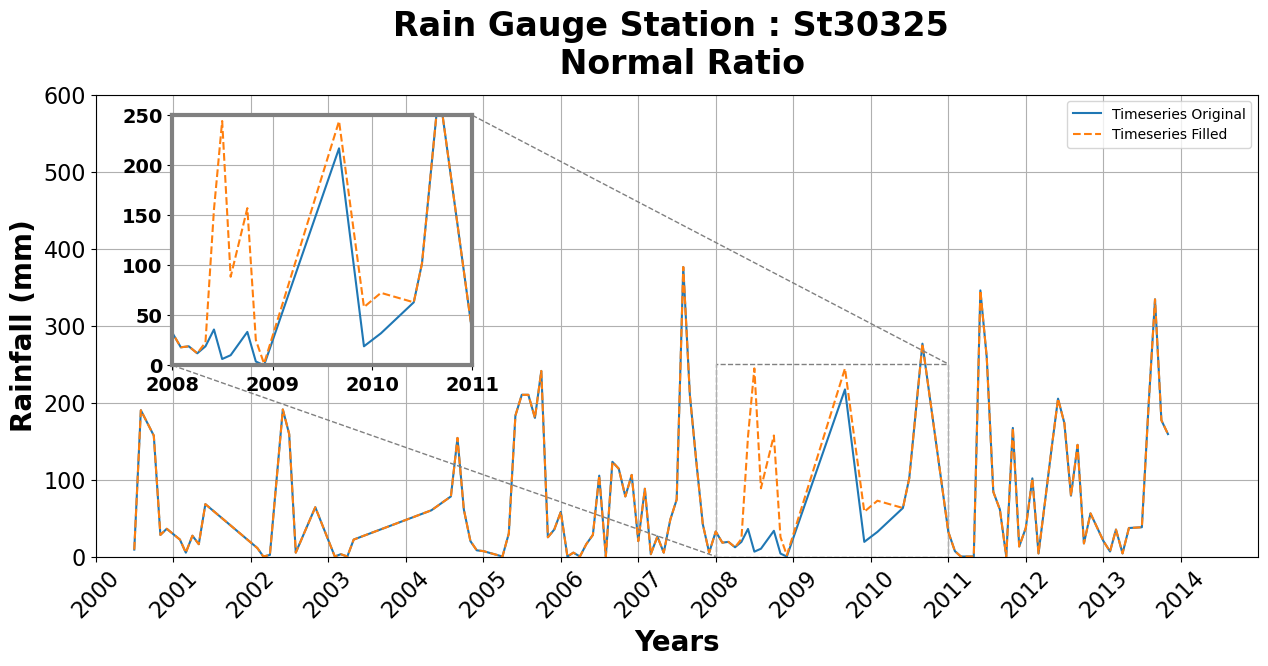

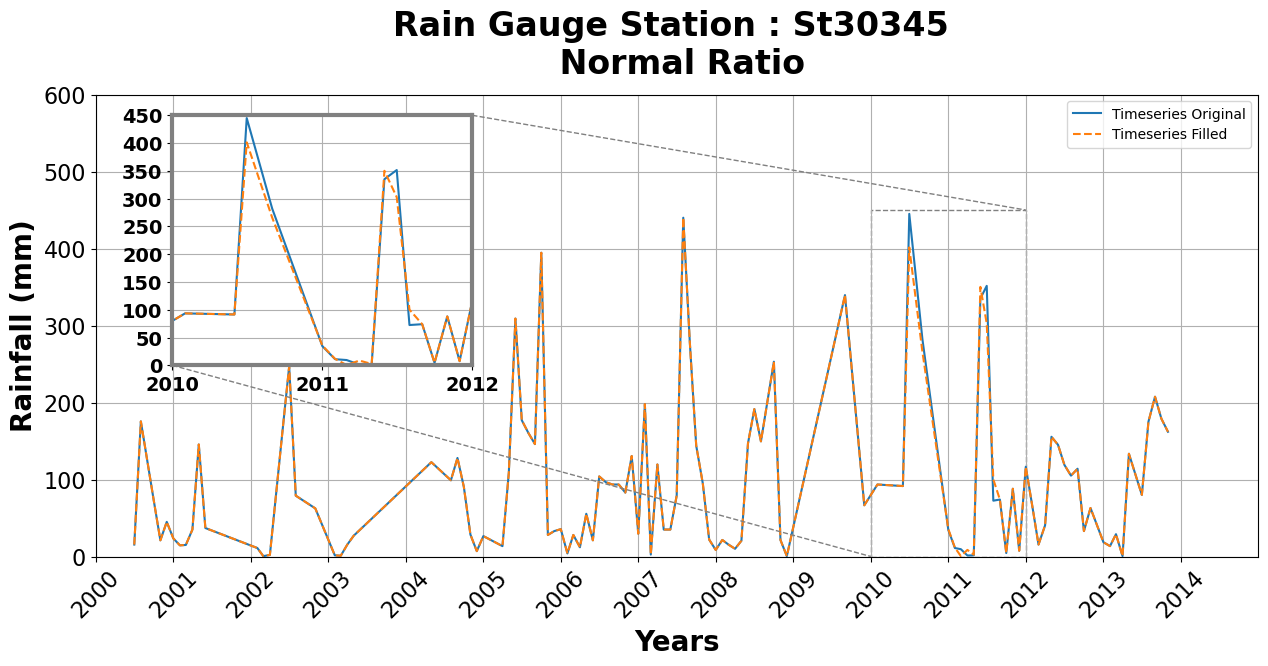

In [67]:
GrafEstZoom(df_2doPeriodPCP_copy,Dataset_NR,Estaciones,limts,dateini_zoom,datefin_zoom,metodoNR,acronim,pathNR_fin)

### Metrics (NR)

In [68]:
df_metricsNR = Calculadora_metrics(df_2doPeriodPCP_copy,Dataset_NR)
df_metricsNR

,R^2,RMSE,MAE,r
St30071,0.97,19.50,4.00,0.98
St30160,0.99,9.63,1.76,0.99
St30169,0.99,11.33,2.08,0.99
St30220,0.97,22.17,4.35,0.98
St30304,0.98,14.12,3.45,0.99
St30319,0.96,17.70,4.07,0.98
St30325,0.88,29.41,6.20,0.94
St30345,0.99,7.12,1.52,1.00


In [69]:
metodoRNCA = 'NR'
pathRNCA_fin = pathOutput
acronimoNRCA = 'NR'

Realizado


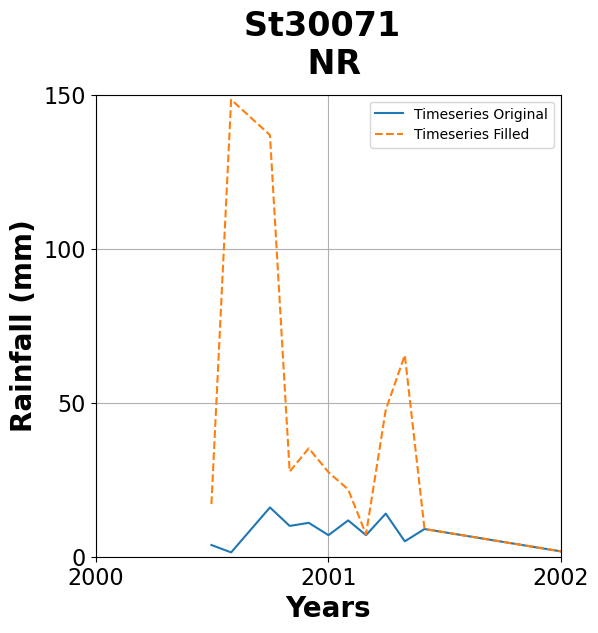

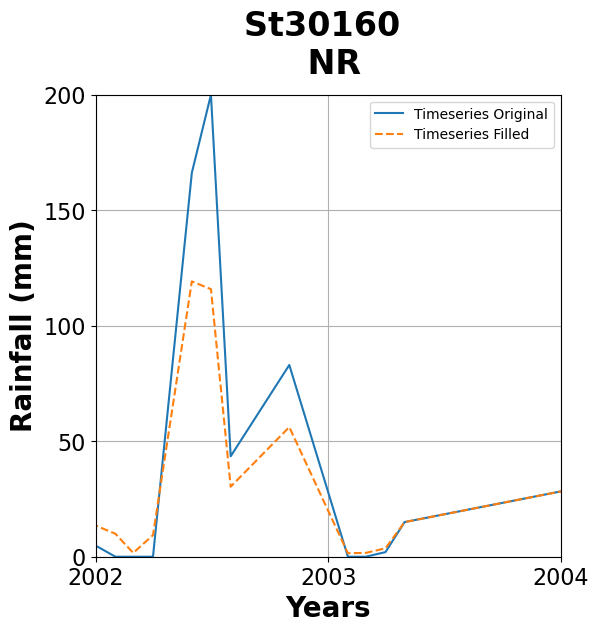

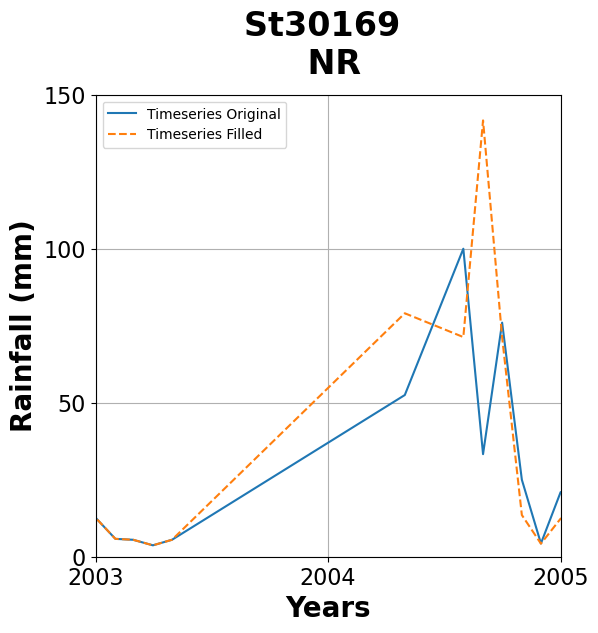

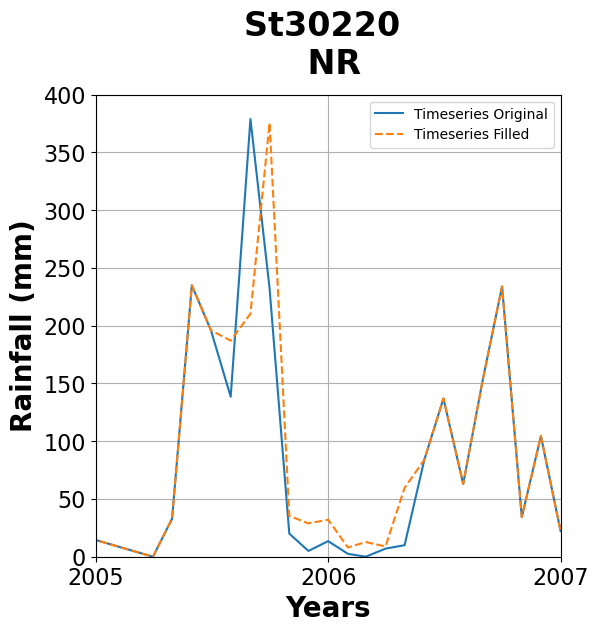

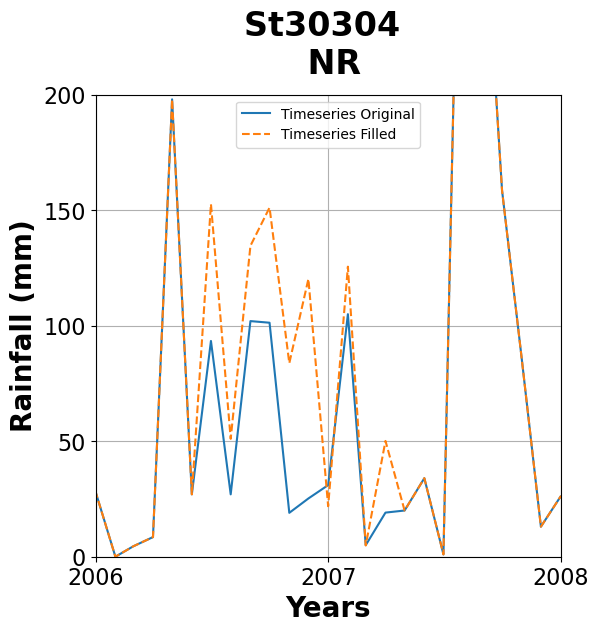

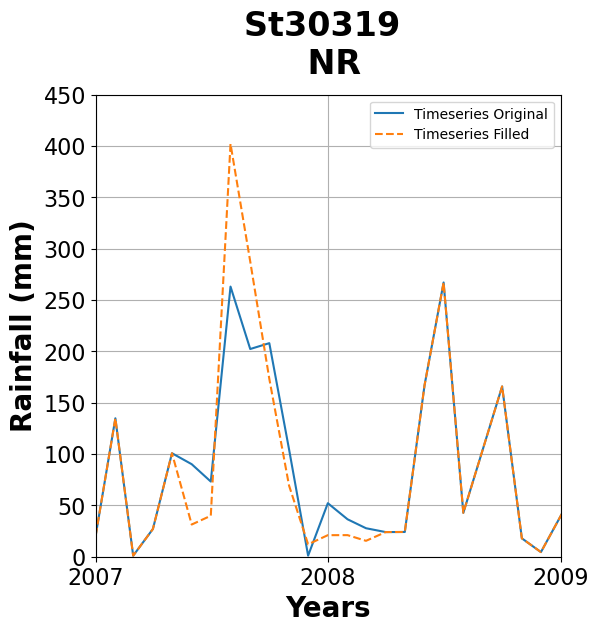

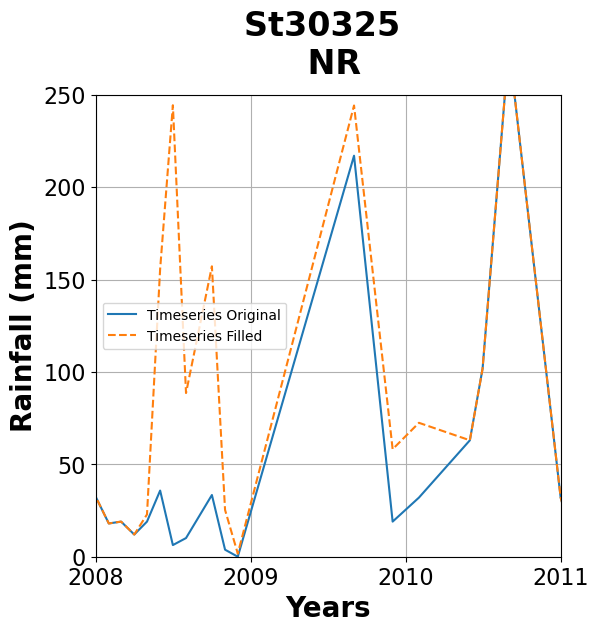

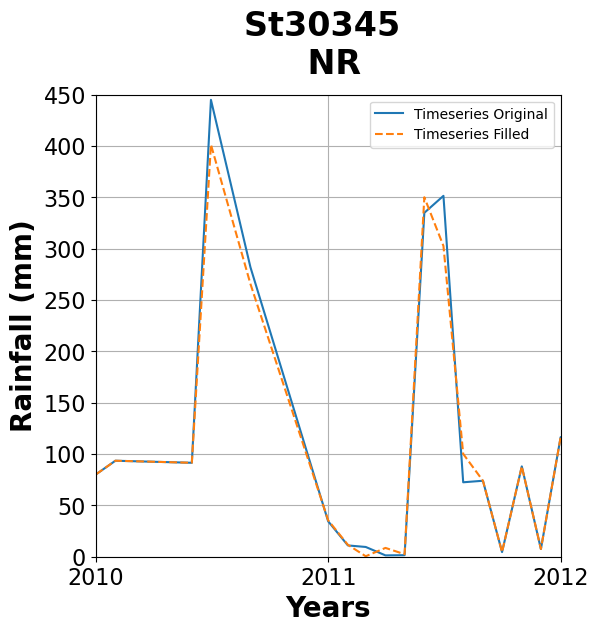

In [70]:
#Prueba funcion
GrafZoom(df_2doPeriodPCP_copy,Dataset_NR,Estaciones,limts,dateini_zoom,datefin_zoom,metodoRNCA,acronimoNRCA,pathRNCA_fin)